<div style="display:flex;align-items:center;justify-content:center;flex-direction:column;padding:18px 0;">
<h1 style="font-family: 'Segoe UI', Roboto, Arial; font-size:48px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">
RANDOM FOREST ASSIGNMENT
</h1>
<p style="margin:8px 0 0; color:#334155; font-size:16px;">A concise workbook covering how to build random forest models, evaluate their performance, and interpret the derived meaningful insights.</p>
</div>

---

<div style="display:flex;gap:12px;flex-wrap:wrap;align-items:center;">
<span style="background:#eef2ff;color:#3730a3;padding:6px 10px;border-radius:8px;font-weight:600;">📘 Basics</span>
<span style="background:#ecfdf5;color:#065f46;padding:6px 10px;border-radius:8px;font-weight:600;">⚙️ Examples</span>
<span style="background:#fff7ed;color:#92400e;padding:6px 10px;border-radius:8px;font-weight:600;">🔁 Exercises</span>
</div>


<details><summary><strong>Notebook info</strong></summary>

- **Author:** Sandipan Roy
- **Assignment Date:** 2026-03-16
- **Assignment Given By:** Karkavel Raja
- **Sections:** Importing Libraries · Data Loading · Data Preprocessing & Transformation Operations · Exploratory Data Analysis (EDA) · Fine-tuning and Optimization · Model Building · Model Evaluation · Model Optimization and Insights

</details>

---



<div style="display:flex;align-items:center;justify-content:center;flex-direction:column;padding:18px 0;">
<h2 style="font-family: 'Segoe UI', Roboto, Arial; font-size:38px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">Problem Statement:</h2>

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">This assignment aims to utilize Random Forest algorithms to analyze given datasets, extracting meaningful insights, and predicting outcomes based on the decision rules learned from the data. By exploring the datasets, students will learn how to build classification models, evaluate their performance, interpret and derive meaningful insights.</p>
</div>

---



<div style="display:flex;align-items:center;justify-content:center;flex-direction:column;padding:18px 0;">
<h2 style="font-family: 'Segoe UI', Roboto, Arial; font-size:38px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">Dataset for the Assignment:</h2>

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">


-   [Credit Risk Classification Dataset | Kaggle](https://www.kaggle.com/datasets/praveengovi/credit-risk-classification-dataset/data)
-   [Stroke Prediction Dataset | Kaggle](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset/data)
-   [Water quality Dataset | Kaggle](https://www.kaggle.com/datasets/mssmartypants/water-quality/data)


</p>
</div>

---


<div style="display:flex;align-items:center;justify-content:center;flex-direction:column;padding:18px 0;">
<h2 style="font-family: 'Segoe UI', Roboto, Arial; font-size:38px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">Business Objective:</h2>

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">

- [Water quality Dataset | Kaggle](https://www.kaggle.com/datasets/mssmartypants/water-quality/data):- Insights into Water Quality: An In-depth Examination

This is a set of data created from imaginary data of water quality in an urban environment. This classification analysis will provide insights into Water Quality:

- To analyze and preprocess the water quality dataset for effective model training.
- To identify significant features influencing water quality prediction.
- To develop and train Machine Learning classification models using the training dataset.
- To evaluate the performance of the models using appropriate evaluation metrics.
- To build a reliable predictive system that can assist in the assessment of water quality.

</p>
</div>

---


<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">1. Setup and Data Preparation:</h3>


---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Install the required libraries if not present.</u></li>
</ul>
</p>

---


In [1]:
!pip install scikit-learn
!pip install statsmodels
!pip install -U imbalanced-learn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Import all the required libraries and orchastrate control over the behaviour and display settings of pandas.</u></li>
</ul>
</p>

---


In [2]:
# Importing warning to disable runtime warnings
import warnings
# Warnings will appear only once
warnings.filterwarnings("ignore")

#=================================================================================

# Importing Numpy Library and aliasing it's name as np
import numpy as np
# Importing Pandas Library and aliasing it's name as pd
import pandas as pd
# Importing the Pyplot Interface from within the Matplotlib Library and aliasing it as plt
import matplotlib.pyplot as plt
# The above line of code can also be written as-
#    from matplotlib import pyplot as plt

# Importing Seaborn Library and aliasing it's name as sns
import seaborn as sns

# Importing the Plotly Express Interface from within the Plotly Library and aliasing it as px
import plotly.express as px

import pickle

from imblearn.combine import SMOTEENN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import cross_val_score, KFold

#=================================================================================

# Unfolding hidden features if the cardinality is high
pd.set_option('display.max_columns', None)
# Unfolding the max feature width for better clearity
pd.set_option('display.max_colwidth', None)
# Unfolding hidden data points if the cardinality is high
pd.set_option('display.max_rows', None)
# Removing restriction over chained assignments operations
pd.set_option('mode.chained_assignment', None)
# To suppress scientific notation over exponential values
pd.set_option('display.float_format', lambda x: '%.5f' % x)

%matplotlib inline

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Acquire data from datasource and bring it in-memory.</u></li>
</ul>
</p>

---


In [3]:
def acquire_data(url, sourceType="csv", verbose=False):
    """
    This function acquires data from the given URL and returns a DataFrame.

    Parameters:
    url (str): The URL from which to acquire the data.
    sourceType (str): The type of the data source (default is "csv").
    verbose (bool): If True, prints the shape of the DataFrame and its columns.

    Returns:
    pd.DataFrame: The acquired data as a DataFrame.
    """

    if sourceType.lower() != "csv":
        raise ValueError("Currently, only 'csv' source type is supported.")

    # Reading the CSV file from the provided URL
    df = pd.read_csv(url)

    # If verbose is True, print the shape of the DataFrame and its columns
    if verbose:
        print(f"DataFrame Shape: {df.shape}, i.e., {df.shape[0]} rows and {df.shape[1]} columns.")
        print(f"DataFrame Columns: {df.columns.tolist()}")

    return df

In [4]:
url = "https://raw.githubusercontent.com/Sandipan-Roy/sr/refs/heads/Dev/ML/Classification/RandomForest/data/raw/waterQuality1.csv"
data = acquire_data(url, verbose=True)

DataFrame Shape: (7999, 21), i.e., 7999 rows and 21 columns.
DataFrame Columns: ['aluminium', 'ammonia', 'arsenic', 'barium', 'cadmium', 'chloramine', 'chromium', 'copper', 'flouride', 'bacteria', 'viruses', 'lead', 'nitrates', 'nitrites', 'mercury', 'perchlorate', 'radium', 'selenium', 'silver', 'uranium', 'is_safe']


---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Analyze the aquired data and perform pre-profiling.</u></li>
</ul>
</p>

---


In [5]:
def analyze_data(df):
    """
    This function performs basic analysis on the given DataFrame and prints the results.

    Parameters:
    df (pd.DataFrame): The DataFrame to analyze.

    Returns:
    __dict__: A dictionary containing the results of the numerical columns and categorical columns list.
    """

    # Displaying the first 5 rows of the DataFrame
    print("First 5 rows of the DataFrame:")
    print(df.head())

    # Displaying the last 5 rows of the DataFrame
    print("\nLast 5 rows of the DataFrame:")
    print(df.tail())

    # Displaying the shape of the DataFrame
    print(f"\nShape of the DataFrame: {df.shape}")

    # Displaying the data types of each column
    print("\nData types of each column:")
    print(df.dtypes)

    #Displaying information about the DataFrame
    print("\nInformation about the DataFrame:")
    print(df.info())

    # Displaying the memory usage of the DataFrame
    print(f"\nMemory usage of the DataFrame: {(df.memory_usage(deep=True)).sum() / 1024:.2f} KB")  # Converting bytes to kilobytes
    print(((df.memory_usage(deep=True)) / 1024).round(2))  # Converting bytes to kilobytes

    # Listing numerical columns
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # Listing categorical columns
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    print("\nWe have {} numerical features: {}".format(len(numerical_cols), numerical_cols))
    print("We have {} categorical features: {}".format(len(categorical_cols), categorical_cols))

    print("\nNumber of duplicated rows: {} ({}% of total rows)".format(
                    df.duplicated().sum(),
                    round(df.duplicated().sum() / df.shape[0] * 100, 2)
                    ))

    if len(numerical_cols) > 0:
      # Displaying summary statistics for numerical columns
      print("\nSummary statistics for numerical columns:")
      print(df.describe())

    if len(categorical_cols) > 0:
      # Displaying summary statistics for categorical columns
      print("\nSummary statistics for categorical columns:")
      print(df.describe(include=['object']))


    # Returning the list of numerical and categorical columns
    return {
        "numerical_columns": numerical_cols if len(numerical_cols) > 0 else None,
        "categorical_columns": categorical_cols if len(categorical_cols) > 0 else None
    }


In [6]:
dictColumns = analyze_data(data)
numerical_columns = dictColumns["numerical_columns"]
categorical_columns = dictColumns["categorical_columns"]

First 5 rows of the DataFrame:
   aluminium ammonia  arsenic  barium  cadmium  chloramine  chromium  copper  \
0    1.65000    9.08  0.04000 2.85000  0.00700     0.35000   0.83000 0.17000   
1    2.32000   21.16  0.01000 3.31000  0.00200     5.28000   0.68000 0.66000   
2    1.01000   14.02  0.04000 0.58000  0.00800     4.24000   0.53000 0.02000   
3    1.36000   11.33  0.04000 2.96000  0.00100     7.23000   0.03000 1.66000   
4    0.92000   24.33  0.03000 0.20000  0.00600     2.67000   0.69000 0.57000   

   flouride  bacteria  viruses    lead  nitrates  nitrites  mercury  \
0   0.05000   0.20000  0.00000 0.05400  16.08000   1.13000  0.00700   
1   0.90000   0.65000  0.65000 0.10000   2.01000   1.93000  0.00300   
2   0.99000   0.05000  0.00300 0.07800  14.16000   1.11000  0.00600   
3   1.08000   0.71000  0.71000 0.01600   1.41000   1.29000  0.00400   
4   0.61000   0.13000  0.00100 0.11700   6.74000   1.11000  0.00300   

   perchlorate  radium  selenium  silver  uranium is_safe  
0

In [7]:
numerical_columns, categorical_columns

(['aluminium',
  'arsenic',
  'barium',
  'cadmium',
  'chloramine',
  'chromium',
  'copper',
  'flouride',
  'bacteria',
  'viruses',
  'lead',
  'nitrates',
  'nitrites',
  'mercury',
  'perchlorate',
  'radium',
  'selenium',
  'silver',
  'uranium'],
 ['ammonia', 'is_safe'])

---
<a name = Section4></a>
### Data Acquisition Observations
---
The dataset consists of the "is_safe" field refers to the whether the waterbody is safe for usage or not. It is integer valued 0 = no disease and 1 = disease.

| Records | Features | Dataset Size |
| :-- | :-- | :-- |
| 7999 | 21 | 1.3+ MB |


| ID | Feature Name | Description of the feature | Data Type |
| :-- | :--| :--| :--|
|01| **aluminium**   | Level of aluminium in water per liter.  | float64 |
|02| **ammonia**   | Level of ammonia in water per liter.  | object |
|03| **arsenic**   | Level of arsenic in water per liter.  | float64 |
|04| **barium**   | Level of barium in water per liter.  | float64 |
|05| **cadmium**   | Level of cadmium in water per liter.  | float64 |
|06| **chloramine**   | Level of chloramine in water per liter.  | float64 |
|07| **chromium**   | Level of chromium in water per liter.  | float64 |
|08| **copper**   | Level of copper in water per liter.  | float64 |
|09| **flouride**   | Level of flouride in water per liter.  | float64 |
|10| **bacteria**   | Level of bacteria in water per liter.  | float64 |
|11| **viruses**   | Level of viruses in water per liter.  | float64 |
|12| **lead**   | Level of lead in water per liter.  | float64 |
|13| **nitrates**   | Level of nitrates in water per liter.  | float64 |
|14| **nitrites**   | Level of nitrites in water per liter.  | float64 |
|15| **mercury**   | Level of mercury in water per liter.  | float64 |
|16| **perchlorate**   | Level of perchlorate in water per liter.  | float64 |
|17| **radium**   | Level of radium in water per liter.  | float64 |
|18| **selenium**   | Level of selenium in water per liter.  | float64 |
|19| **silver**   | Level of silver in water per liter.  | float64 |
|20| **uranium**   | Level of uranium in water per liter.  | float64 |
|21| **is_safe**   | Whether this water body is safe or not  | object |


---

- Data types of all the features except 'ammonia' and 'is_safe' looks appropriate.
- There are no missing values in any features.
- Number of duplicated rows: 0 (0.0% of total rows)
- Memory usage of the DataFrame: 1996.12 KB

In [8]:
def get_proportion_of_categorical_values(df, column_name):
    """
    This function calculates the proportion of each unique value in a categorical column.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the categorical column.
    column_name (str): The name of the categorical column for which to calculate proportions.

    Returns:
    None (prints proportions for each column).
    """
    not_in_list2 = list(set(column_name) - set(df.columns))

    # Checking if the specified column is in the DataFrame
    if len(not_in_list2) > 0:
        raise ValueError(f"Column(s) '{', '.join(not_in_list2)}' not found in the DataFrame.")

    # Calculating the proportion of each unique value in the specified column
    for col in column_name:
        proportions = df[col].value_counts(normalize=True) * 100  # Multiplying by 100 to get percentages
        print(f"\nProportions for column '{col}' in %:")
        print(proportions)
        print("-" * 50)  # Adding a separator for better readability


In [9]:
get_proportion_of_categorical_values(data, ["is_safe"])


Proportions for column 'is_safe' in %:
is_safe
0       88.56107
1       11.40143
#NUM!    0.03750
Name: proportion, dtype: float64
--------------------------------------------------


In [10]:
# Identify rows where the 'ammonia' column contains non-numeric values
non_numeric_mask = pd.to_numeric(data['ammonia'], errors='coerce').isna()
non_numeric_rows = data[non_numeric_mask]

# To see only the unique non-numeric values
unique_non_numeric = data[non_numeric_mask]['ammonia'].unique()
unique_non_numeric

array(['#NUM!'], dtype=object)

---
<a name = Section2></a>
#### Insights:

- There are approx 0.04% data in our target column where actual value is missing or somehow got replaced with '#NUM!'
- Similar issue can be observed in case of the column 'ammonia' where we are having values '#NUM!'

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Perform Data Wrangling.</u></li>
</ul>
</p>

---


In [11]:
def copy_dataframe(df):
    """
    This function creates and returns a copy of the given DataFrame
    to ensure that the original DataFrame remains unchanged during analysis.
    Also it removes duplicate data points if there are any in the DataFrame.

    Parameters:
    df (pd.DataFrame): The DataFrame to copy.

    Returns:
    pd.DataFrame: A copy of the input DataFrame.
    """
    df_copy = df.copy()

    # dropping duplicate data and keeping the first occurrence of each duplicate
    df_copy.drop_duplicates(inplace=True, keep='first')
    return df_copy

In [12]:
clean_data = copy_dataframe(data)

clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7999 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7999 non-null   float64
 1   ammonia      7999 non-null   object 
 2   arsenic      7999 non-null   float64
 3   barium       7999 non-null   float64
 4   cadmium      7999 non-null   float64
 5   chloramine   7999 non-null   float64
 6   chromium     7999 non-null   float64
 7   copper       7999 non-null   float64
 8   flouride     7999 non-null   float64
 9   bacteria     7999 non-null   float64
 10  viruses      7999 non-null   float64
 11  lead         7999 non-null   float64
 12  nitrates     7999 non-null   float64
 13  nitrites     7999 non-null   float64
 14  mercury      7999 non-null   float64
 15  perchlorate  7999 non-null   float64
 16  radium       7999 non-null   float64
 17  selenium     7999 non-null   float64
 18  silver       7999 non-null   float64
 19  uraniu

In [13]:
to_be_removed_index = clean_data[non_numeric_mask==True].index

In [14]:
clean_data[non_numeric_mask]

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,viruses,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
7551,0.03000,#NUM!,0.08000,0.79000,0.07000,0.08000,0.05000,0.58000,0.34000,0.00000,0.00000,0.18300,4.37000,1.43000,0.00700,0.62000,2.54000,0.07000,0.05000,0.05000,#NUM!
7568,0.06000,#NUM!,0.07000,1.72000,0.08000,0.32000,0.01000,1.11000,0.61000,0.00000,0.00000,0.17800,12.10000,2.03000,0.00800,1.37000,2.05000,0.06000,0.10000,0.07000,#NUM!
7890,0.01000,#NUM!,0.08000,0.49000,0.00000,0.07000,0.09000,0.06000,0.72000,0.57000,0.00000,0.08800,9.57000,1.45000,0.00900,7.67000,7.70000,0.03000,0.05000,0.02000,#NUM!


In [15]:
clean_data.drop(index=to_be_removed_index, axis=0, inplace=True)
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7996 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7996 non-null   float64
 1   ammonia      7996 non-null   object 
 2   arsenic      7996 non-null   float64
 3   barium       7996 non-null   float64
 4   cadmium      7996 non-null   float64
 5   chloramine   7996 non-null   float64
 6   chromium     7996 non-null   float64
 7   copper       7996 non-null   float64
 8   flouride     7996 non-null   float64
 9   bacteria     7996 non-null   float64
 10  viruses      7996 non-null   float64
 11  lead         7996 non-null   float64
 12  nitrates     7996 non-null   float64
 13  nitrites     7996 non-null   float64
 14  mercury      7996 non-null   float64
 15  perchlorate  7996 non-null   float64
 16  radium       7996 non-null   float64
 17  selenium     7996 non-null   float64
 18  silver       7996 non-null   float64
 19  uranium    

In [16]:
get_proportion_of_categorical_values(clean_data, ["is_safe"])


Proportions for column 'is_safe' in %:
is_safe
0   88.59430
1   11.40570
Name: proportion, dtype: float64
--------------------------------------------------


---
<a name = Section2></a>
#### Insights:

- Data is highly imbalanced

In [17]:
clean_data["ammonia"] = clean_data["ammonia"].astype("float64")
clean_data["is_safe"] = clean_data["is_safe"].astype("int16")
numerical_columns.append("ammonia")
categorical_columns = ["is_safe"]
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7996 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7996 non-null   float64
 1   ammonia      7996 non-null   float64
 2   arsenic      7996 non-null   float64
 3   barium       7996 non-null   float64
 4   cadmium      7996 non-null   float64
 5   chloramine   7996 non-null   float64
 6   chromium     7996 non-null   float64
 7   copper       7996 non-null   float64
 8   flouride     7996 non-null   float64
 9   bacteria     7996 non-null   float64
 10  viruses      7996 non-null   float64
 11  lead         7996 non-null   float64
 12  nitrates     7996 non-null   float64
 13  nitrites     7996 non-null   float64
 14  mercury      7996 non-null   float64
 15  perchlorate  7996 non-null   float64
 16  radium       7996 non-null   float64
 17  selenium     7996 non-null   float64
 18  silver       7996 non-null   float64
 19  uranium    


<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Uni-variate Analysis.</u></li>
</ul>
</p>

---


In [18]:
total_datapoints = clean_data.shape[0]
print(f"Total number of data points: {total_datapoints}")

Total number of data points: 7996


In [19]:
def plot_univariate_distribution(df, column, plot_type="histogram", plot_width=12, plot_height=4):
    """
    This function plots the univariate distribution of a specified column in the DataFrame 
    using the specified plot type (histogram, boxplot, or countplot). It also calculates 
    and prints the Interquartile Range (IQR) of the specified column.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    column (str): The name of the column to plot.
    plot_type (str): The type of plot to create ("histogram" or "boxplot" or "countplot").

    Returns:
    None
    """

    fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(plot_width, plot_height))

    sns.kdeplot(df[column], shade=True, color='blue', ax=ax1)
    ax1.set_title(f'Distribution of {column.capitalize()}')
    ax1.set_xlabel(column.capitalize())
    #plt.figure(figsize=(6, 4))
    
    #plt.title(f'Distribution of {column.capitalize()}')
    #plt.xlabel(column.capitalize())

    if plot_type != "boxplot":
        if plot_type == "histogram":
            ax2 = sns.histplot(df[column], kde=True, color='blue')
            ax2.set_ylabel('Frequency')
            ax2.set_title(f'{plot_type.capitalize()} of {column.capitalize()}')
            #plt.ylabel('Frequency')
            #plt.title(f'{plot_type.capitalize()} of {column.capitalize()}')
        elif plot_type == "countplot":
            ax2 = sns.countplot(x=df[column], palette='magma')
            ax2.set_ylabel('Count')
            ax2.set_title(f'{plot_type.capitalize()} of {column.capitalize()}')
        else:
            raise ValueError("Invalid plot type. Use 'histogram' or 'boxplot' or 'countplot'.")

        for p in ax2.patches:
            percentage = '{:.2f}%'.format(100 * p.get_height() / total_datapoints)
            x = p.get_x() + p.get_width()/5
            y = p.get_y() + p.get_height()
            ax2.annotate(percentage, (x, y))

    else:
        ax2 = sns.boxplot(x=df[column], palette='magma')
        ax2.set_title(f'{plot_type.capitalize()} of {column.capitalize()}')


    
    ax2.set_xlabel(column.capitalize())
    plt.show()

    iqr_column = df[column].quantile(0.75) - df[column].quantile(0.25)
    print(f" IQR of {column.capitalize()}: {iqr_column}")

In [20]:
numerical_columns, categorical_columns

(['aluminium',
  'arsenic',
  'barium',
  'cadmium',
  'chloramine',
  'chromium',
  'copper',
  'flouride',
  'bacteria',
  'viruses',
  'lead',
  'nitrates',
  'nitrites',
  'mercury',
  'perchlorate',
  'radium',
  'selenium',
  'silver',
  'uranium',
  'ammonia'],
 ['is_safe'])

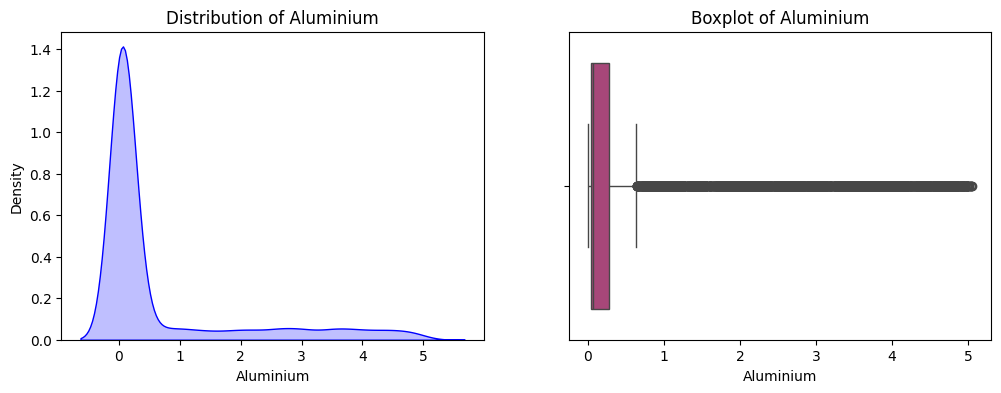

 IQR of Aluminium: 0.24000000000000002


In [21]:
plot_univariate_distribution(clean_data, column="aluminium", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- About 50% data lies within 0.07
- About 75% data lies within 0.28
- Data is right skewed, need further analysis

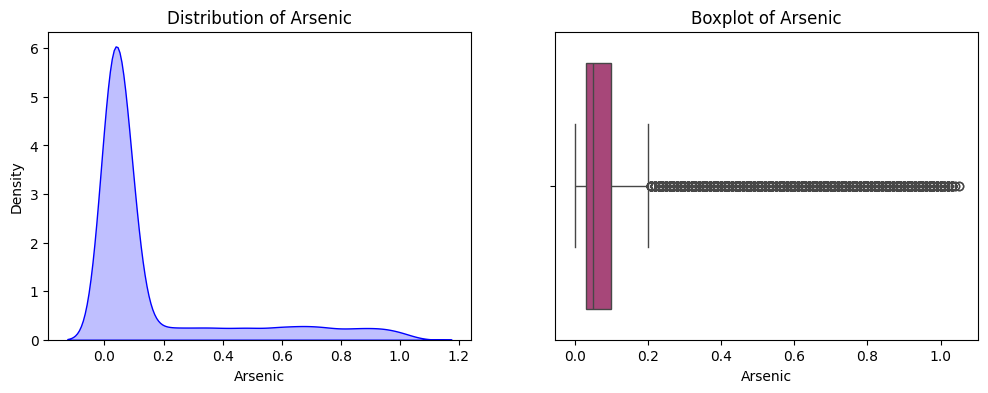

 IQR of Arsenic: 0.07


In [22]:
plot_univariate_distribution(clean_data, column="arsenic", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- About 75% data is within 0.1 on the scale.
- Data is right skewed, need further analysis

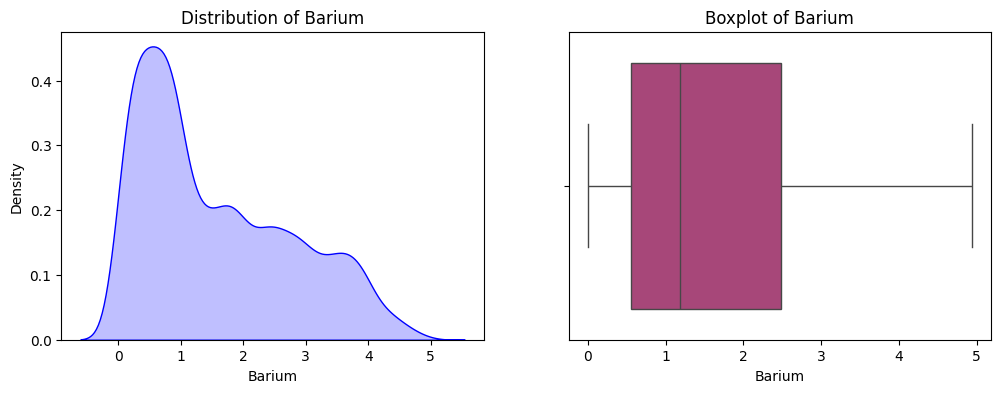

 IQR of Barium: 1.9224999999999999


In [23]:
plot_univariate_distribution(clean_data, column="barium", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- Around 75% data is within 2.48 on the scale
- Data is right skewed, need further analysis

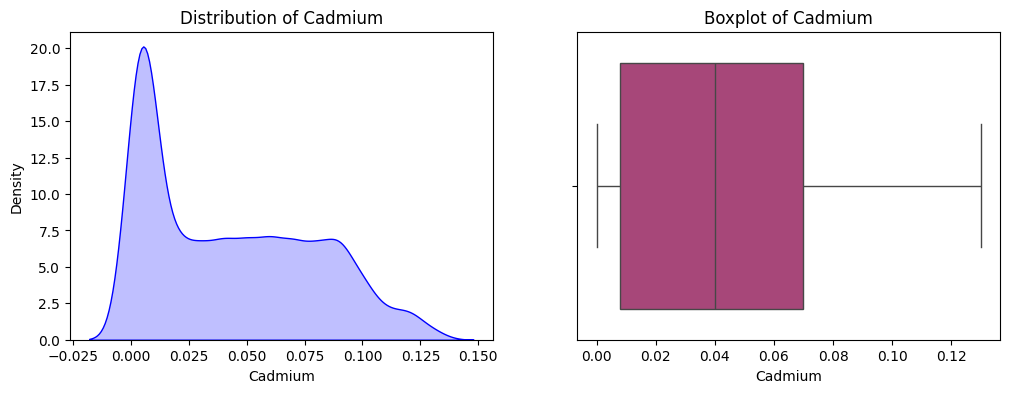

 IQR of Cadmium: 0.062000000000000006


In [24]:
plot_univariate_distribution(clean_data, column="cadmium", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- About 75% data is within 0.070 on the scale
- Data is right skewed, need further analysis

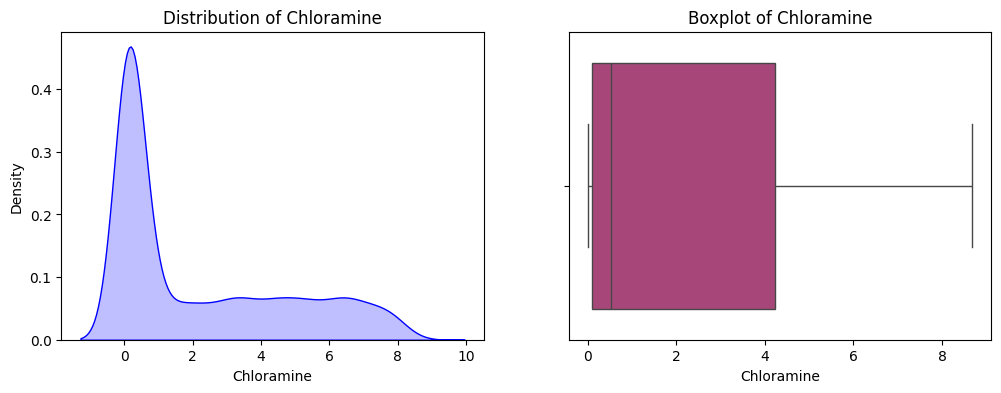

 IQR of Chloramine: 4.140000000000001


In [25]:
plot_univariate_distribution(clean_data, column="chloramine", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- About 75% data is within the scale of 4.24
- Data is right skewed, need further analysis

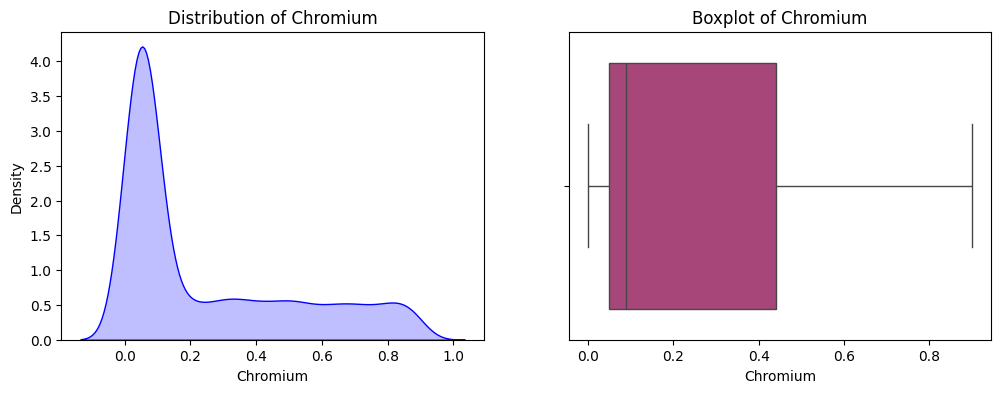

 IQR of Chromium: 0.39


In [26]:
plot_univariate_distribution(clean_data, column="chromium", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- About 75% data is within 0.44 on the scale
- Data is right skewed, need further analysis

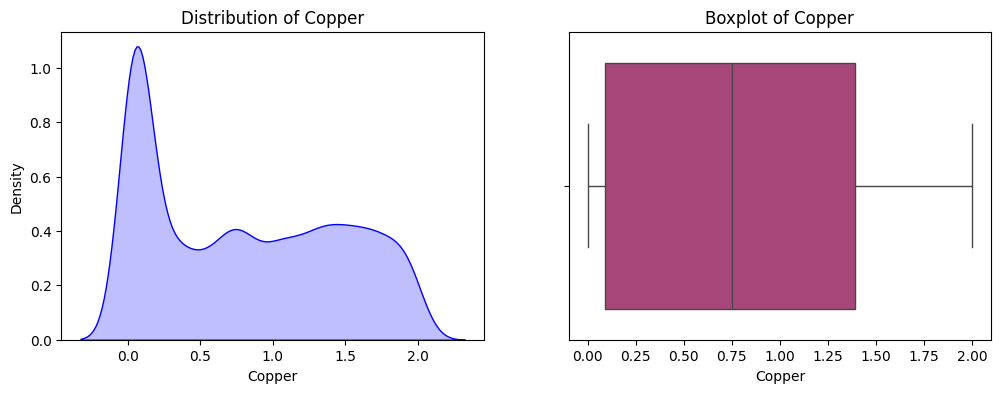

 IQR of Copper: 1.2999999999999998


In [27]:
plot_univariate_distribution(clean_data, column="copper", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- 50% data is within the range of 0.75 on the scale
- 75% data is within the range of 1.39 on the scale
- Data is right skewed, need further analysis

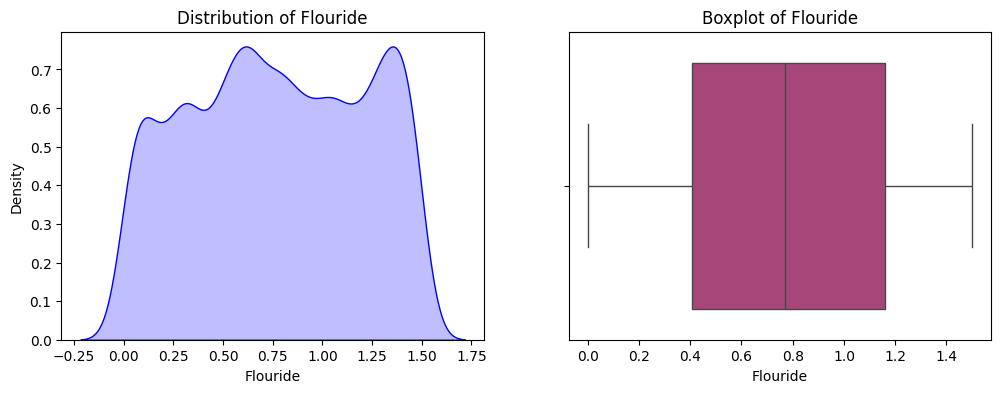

 IQR of Flouride: 0.7525


In [28]:
plot_univariate_distribution(clean_data, column="flouride", plot_type="boxplot")

In [29]:
clean_data["flouride"].min(), clean_data["flouride"].max()

(np.float64(0.0), np.float64(1.5))

---
<a name = Section2></a>
#### Insights:

- 25% data is within the range of 0.405 on the scale
- 50% data is within the range of 0.77 on the scale
- 75% data is within the range of 1.16 on the scale
- The distribution is bimodal (has two peaks) - one around 0.4-0.5 and another around 1.0-1.2
- Most data appears concentrated between 0.0 and 1.5
- The distribution doesn't follow a perfect normal curve, suggesting fluoride levels might vary by water source or treatment process

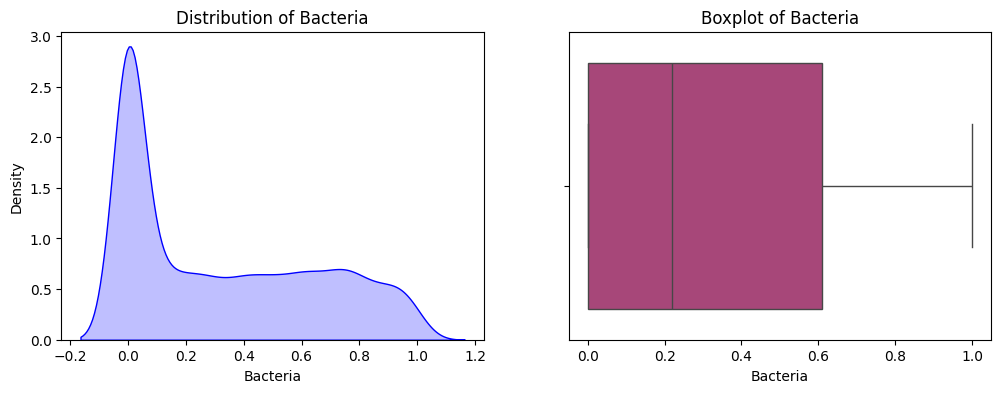

 IQR of Bacteria: 0.61


In [30]:
plot_univariate_distribution(clean_data, column="bacteria", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- 50% data is within the range of 0.22 on the scale
- 75% data is within the range of 0.61 on the scale
- Data is right skewed, need further analysis

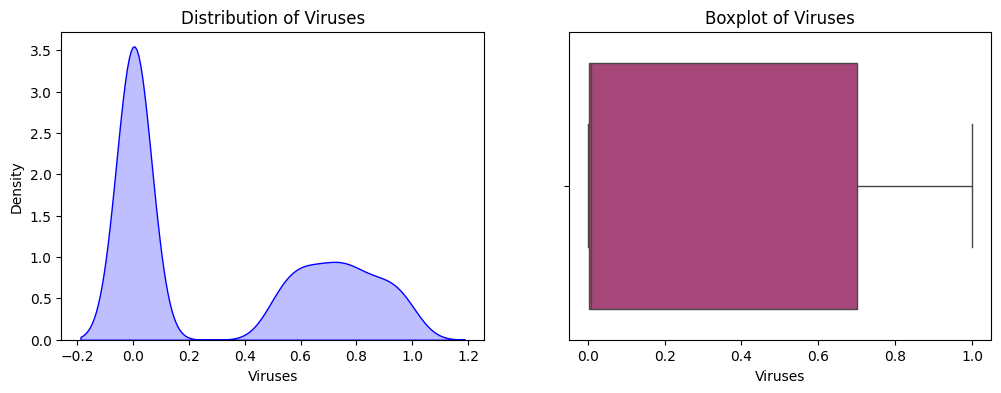

 IQR of Viruses: 0.698


In [31]:
plot_univariate_distribution(clean_data, column="viruses", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- The data shows two distinct peaks, indicating two separate concentration patterns:
    - First Peak (~0.01-0.05): Represents water samples with very low virus levels (high frequency)
    - Second Peak (~0.6-0.8): Represents water samples with moderate virus levels (medium frequency)
- Gap Between Peaks (0.2-0.5 region): Very few samples fall in this range, showing a clear separation between low and moderate contamination levels
- This pattern suggests the presence of two types of water sources or testing conditions.
- Most virus concentrations fall between 0 and 1.0 units per liter
- 25% data is within the range of 0.002 units per liter
- 50% data is within the range of 0.008 units per liter
- 75% data is within the range of 0.7 units per liter
- Data shows right skew with the concentration of samples toward lower values. Need further analysis

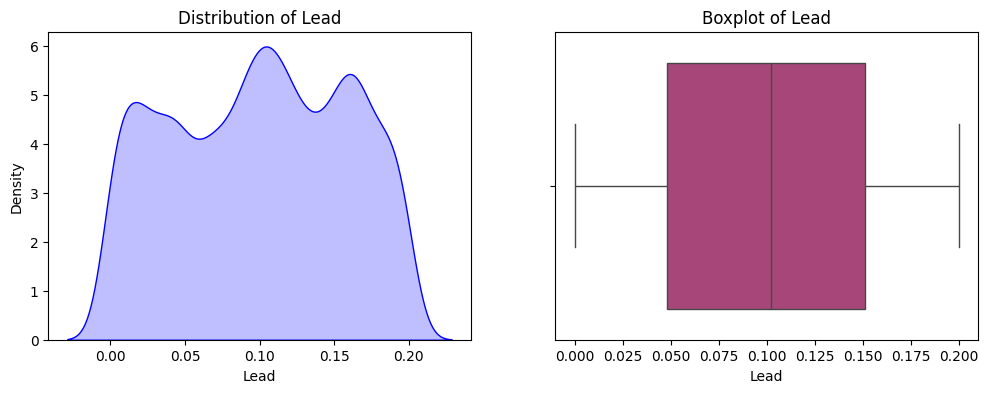

 IQR of Lead: 0.103


In [32]:
plot_univariate_distribution(clean_data, column="lead", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- 25% data is within the range of 0.048 units per liter
- 50% data is within the range of 0.102 units per liter
- 75% data is within the range of 0.151 units per liter
- The distribution doesn't follow a perfect normal curve, suggesting lead levels might vary by water source or treatment process

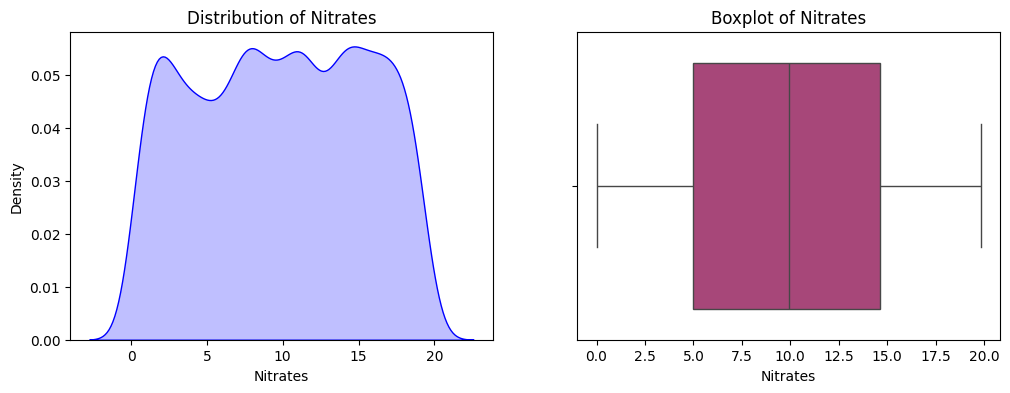

 IQR of Nitrates: 9.61


In [33]:
plot_univariate_distribution(clean_data, column="nitrates", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- 25% data is within the range of 5.00 units per liter
- 50% data is within the range of 9.93 units per liter
- 75% data is within the range of 14.61 units per liter
- The distribution is bimodal (has two peaks) - one around 7.0-8.5 and another around 15.0-17.5
- The distribution doesn't follow a perfect normal curve, suggesting nitrates levels might vary by water source or treatment process

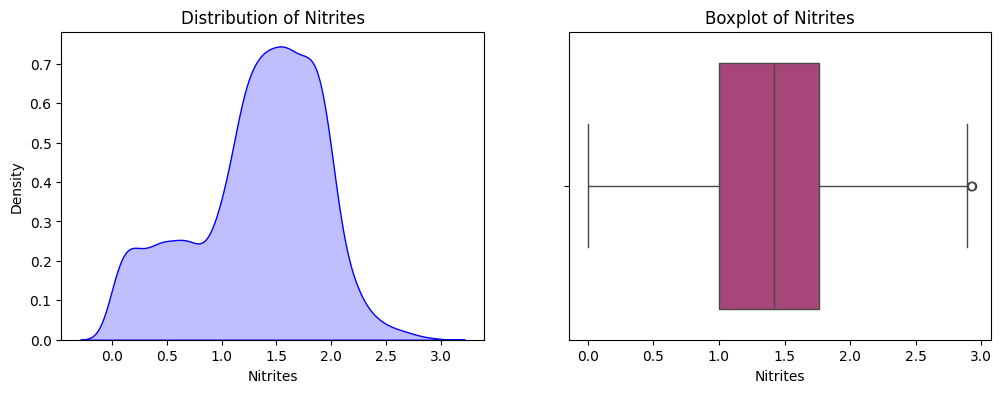

 IQR of Nitrites: 0.76


In [34]:
plot_univariate_distribution(clean_data, column="nitrites", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- 25% data is within the range of 1.00 units per liter
- 50% data is within the range of 1.42 units per liter
- 75% data is within the range of 1.76 units per liter
- The curve reveals the probability density at different concentration levels
- The distribution is relatively symmetric (bell-shaped curve)
- The boxplot confirms moderate spread with the majority of data concentrated in the central region
- There's one outlier visible on the right side (the circle marker), indicating some water samples have unusually high nitrite levels

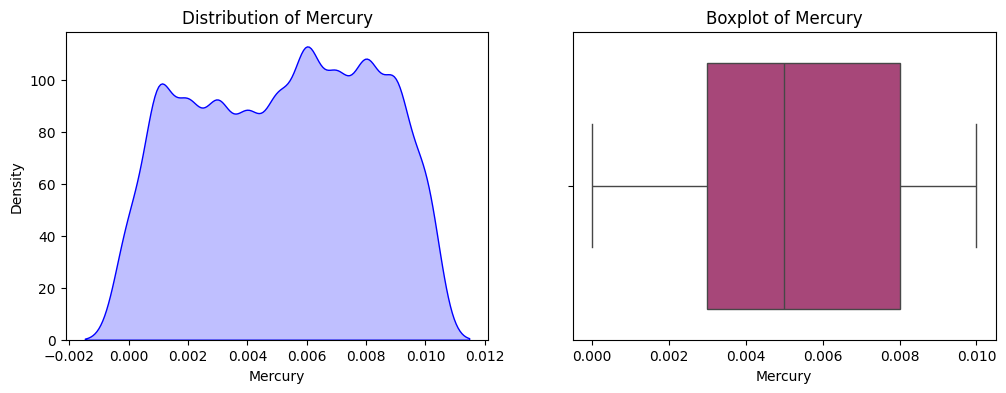

 IQR of Mercury: 0.005


In [35]:
plot_univariate_distribution(clean_data, column="mercury", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- 25% data is within the range of 0.003 units per liter
- 50% data is within the range of 0.005 units per liter
- 75% data is within the range of 0.008 units per liter
- The distribution is roughly bimodal with two peaks, suggesting two concentration patterns in the water samples
- Mercury levels are quite low and consistent, ranging from about 0 to 0.01 units per liter
- The data appears to be well-contained without severe outliers, suggesting stable mercury contamination patterns

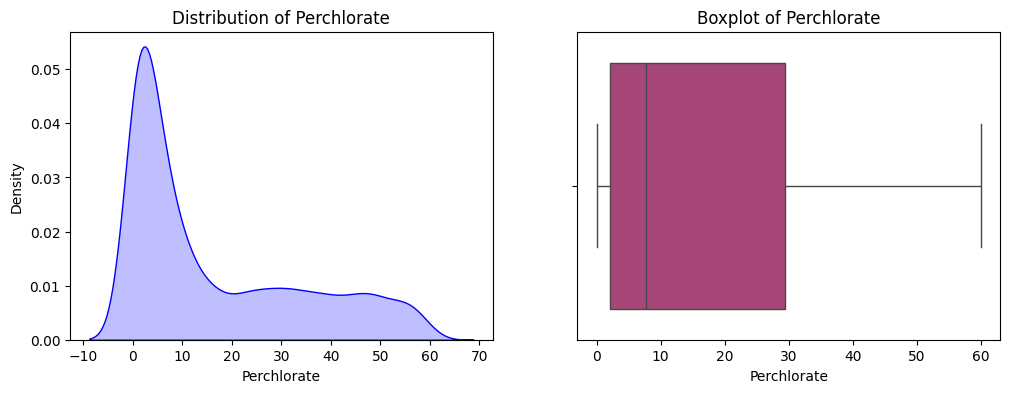

 IQR of Perchlorate: 27.317500000000003


In [36]:
plot_univariate_distribution(clean_data, column="perchlorate", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- 25% data is within the range of 2.17 units per liter
- 50% data is within the range of 7.74 units per liter
- 75% data is within the range of 29.48 units per liter
- Data is right skewed, need further analysis

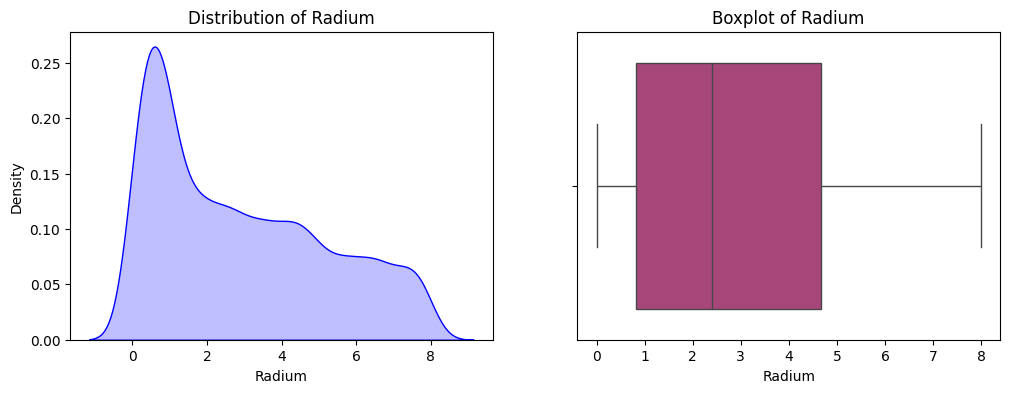

 IQR of Radium: 3.85


In [37]:
plot_univariate_distribution(clean_data, column="radium", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- 25% data is within the range of 0.82 units per liter
- 50% data is within the range of 2.41 units per liter
- 75% data is within the range of 4.67 units per liter
- Data is right skewed, need further analysis

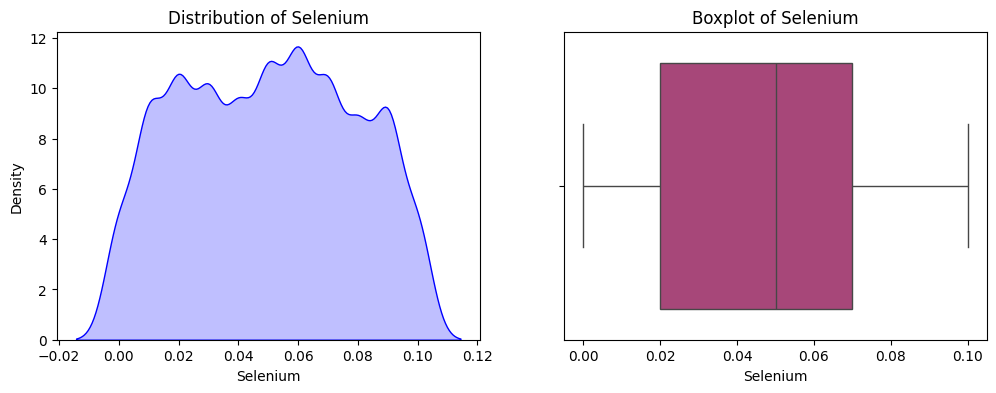

 IQR of Selenium: 0.05


In [38]:
plot_univariate_distribution(clean_data, column="selenium", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- 25% data is within the range of 0.02 units per liter
- 50% data is within the range of 0.05 units per liter
- 75% data is within the range of 0.07 units per liter
- The curve suggests relatively uniform selenium presence across the water samples
- A few data points extending above ~0.09, indicating some samples with unusually high selenium levels

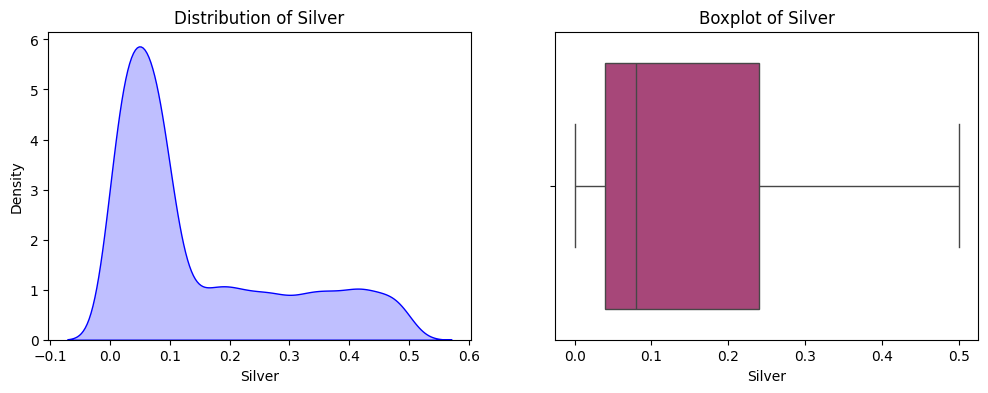

 IQR of Silver: 0.19999999999999998


In [39]:
plot_univariate_distribution(clean_data, column="silver", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- 25% data is within the range of 0.04 units per liter
- 50% data is within the range of 0.08 units per liter
- 75% data is within the range of 0.24 units per liter
- Data is right skewed, need further analysis

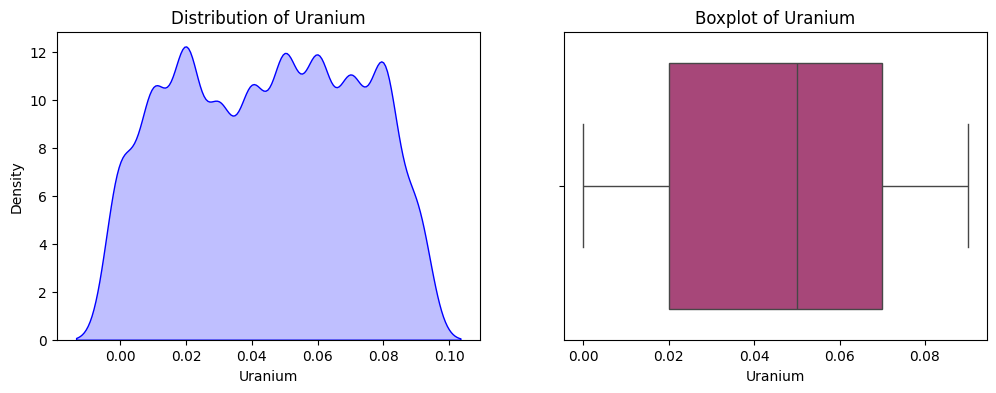

 IQR of Uranium: 0.05


In [40]:
plot_univariate_distribution(clean_data, column="uranium", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- 25% data is within the range of 0.02 units per liter
- 50% data is within the range of 0.05 units per liter
- 75% data is within the range of 0.07 units per liter
- The curve suggests relatively uniform uranium presence across the water samples
- The data appears to be well-contained without severe outliers, suggesting stable uranium contamination patterns

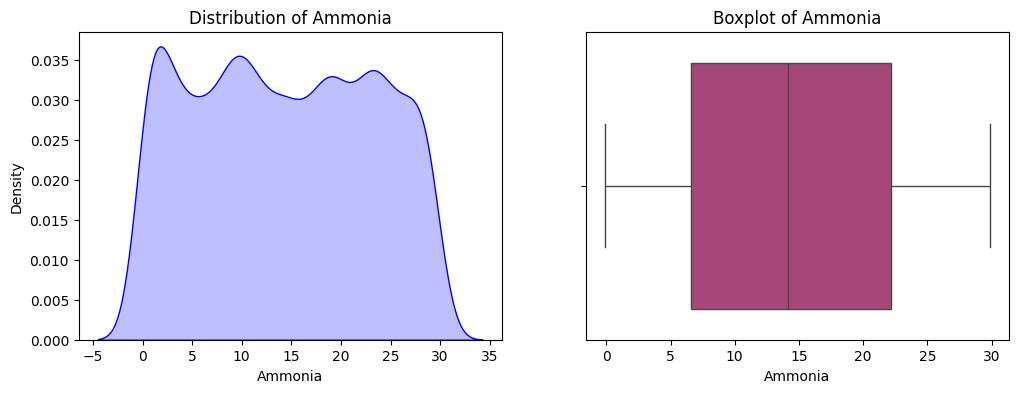

 IQR of Ammonia: 15.555


In [41]:
plot_univariate_distribution(clean_data, column="ammonia", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- 25% data is within the range of 6 units per liter
- 50% data is within the range of 14 units per liter
- 75% data is within the range of 22.5 units per liter
- The curve suggests relatively uniform ammonia presence across the water samples
- The data appears to be well-contained without severe outliers, suggesting stable ammonia contamination patterns


<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Bi-variate Analysis.</u></li>
</ul>
</p>

---


In [42]:
def plot_bivariate_relationship(df, x_column, y_column, x_label=None, y_label=None, plot_type="scatter", plot_width=6, plot_height=4):
    """
    This function plots the bivariate relationship between two specified columns in the DataFrame.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    x_column (str): The name of the column to be plotted on the x-axis.
    y_column (str): The name of the column to be plotted on the y-axis.
    x_label (str): The label for the x-axis.
    y_label (str): The label for the y-axis.
    plot_type (str): The type of plot to create ("scatter" or "line" or "crosstab" or "boxplot").
    plot_width (int): The width of the plot in inches.
    plot_height (int): The height of the plot in inches.

    Returns:
    None
    """

    fig = plt.figure(figsize=(plot_width, plot_height))

    if plot_type == "scatter":
        ax = sns.scatterplot(x=df[x_column], y=df[y_column], color='blue')

        plt.title(f'Scatter Plot of {y_column.capitalize() if y_label is None else y_label.capitalize()} vs {x_column.capitalize() if x_label is None else x_label.capitalize()}')

    elif plot_type == "line":
        ax = sns.lineplot(x=df[x_column], y=df[y_column], color='blue')

        plt.title(f'Line Plot of {y_column.capitalize() if y_label is None else y_label.capitalize()} vs {x_column.capitalize() if x_label is None else x_label.capitalize()}')

    elif plot_type == "countplot":
        ax = sns.countplot(x=df[x_column], hue=df[y_column], palette='magma')

        for p in ax.patches:
            percentage = '{:.2f}%'.format(100 * p.get_height() / total_datapoints)
            x = p.get_x() + p.get_width()/5
            y = p.get_y() + p.get_height()
            ax.annotate(percentage, (x, y))

        plt.title(f'Count Plot of {y_column.capitalize() if y_label is None else y_label.capitalize()} vs {x_column.capitalize() if x_label is None else x_label.capitalize()}')
    elif plot_type == "crosstab":
        crosstab = pd.crosstab(df[x_column], df[y_column])
        ax = crosstab.plot(kind='bar', stacked=True, figsize=fig)

        for p in ax.patches:
            percentage = '{:.2f}%'.format(100 * p.get_height() / total_datapoints)
            x = p.get_x() + p.get_width()/5
            y = p.get_y() + p.get_height()
            ax.annotate(percentage, (x, y))

        plt.title(f'Cross-tabulation of {y_column.capitalize() if y_label is None else y_label.capitalize()} vs {x_column.capitalize() if x_label is None else x_label.capitalize()}')

    elif plot_type == "boxplot":
        ax = sns.boxplot(x=df[x_column], y=df[y_column])

        plt.title(f'Box Plot of {y_column.capitalize() if y_label is None else y_label.capitalize()} vs {x_column.capitalize() if x_label is None else x_label.capitalize()}')

    else:
        raise ValueError("Invalid plot type. Use 'scatter' or 'line'  or 'crosstab' or 'boxplot'.")


    plt.ylabel(y_column.capitalize() if y_label is None else y_label.capitalize())
    plt.xlabel(x_column.capitalize() if x_label is None else x_label.capitalize())

    plt.grid(visible=True)
    plt.show()

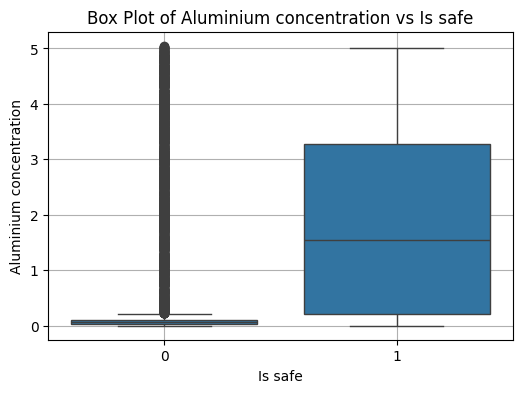

In [43]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="aluminium", plot_type="boxplot", x_label="Is Safe", y_label="Aluminium Concentration")

---
<a name = Section2></a>
#### Insights:

- There's a clear inverse correlation:
    - Unsafe water (0) → Low aluminium concentration (mean concentration < 0.1)
    - Safe water (1) → Higher aluminium concentration (mean concentration 1.5-1.7)
- For Is_Safe = 0 (Unsafe Water): Multiple outliers extending up to ~5.0 units/liter (shown as single points and the tall line above the box)
- Unsafe water samples predominantly have minimal aluminium, but some anomalous samples have significantly higher levels
- For Is_Safe = 1 (Safe Water): Spans from near 0 to approx 3.3 units/liter
- Safe water contains moderate to higher aluminium levels consistently

This suggests that higher aluminium levels are actually associated with safer water, which may indicate that aluminium is intentionally added as part of the water treatment/purification process.

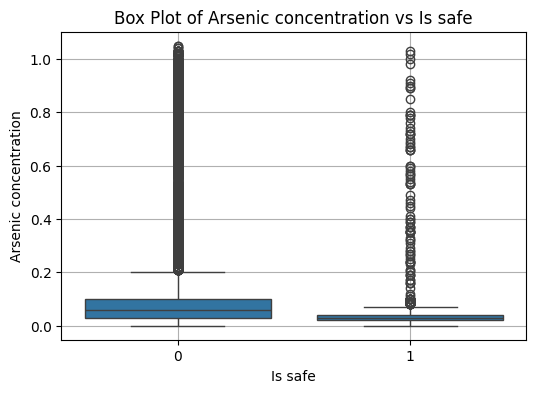

In [44]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="arsenic", plot_type="boxplot", x_label="Is Safe", y_label="Arsenic Concentration")

---
<a name = Section2></a>
#### Insights:

- For Is_Safe = 0 (Unsafe Water): 
  - 50% of data lies within the range of ~0.05 to ~0.12 units per liter (IQR centered around 0.08-0.10)
  - The median is approximately 0.08 units per liter
  - Multiple outliers extending significantly upward to ~1.0 units per liter (shown as circles)
  - Indicates most unsafe water samples have low arsenic, but some anomalous samples exhibit high contamination

- For Is_Safe = 1 (Safe Water):
  - 50% of data is tightly concentrated very close to 0 (IQR is extremely compressed)
  - The median appears to be nearly at 0.0 units per liter
  - Still has outliers extending up to ~1.0 units per liter (showing similar range to unsafe water)
  - Majority of safe water samples have negligible arsenic levels

- Comparative Analysis:
  - Inverse Correlation: 
        - Unsafe water (0) actually shows slightly higher central arsenic concentration than safe water (1)
  - Outlier Similarity: 
        - Both groups exhibit similar outlier patterns extending to ~1.0 units/liter, suggesting arsenic contamination is not a strong discriminator between safe and unsafe water
  - Concentration Pattern: 
        - The distribution suggests that arsenic alone may not be the primary determinant of water safety in this dataset
  - Data Quality Observation: 
        - The presence of numerous outliers in both groups suggests either data variation due to different testing conditions or that other contaminants play a more critical role in determining water safety than arsenic alone

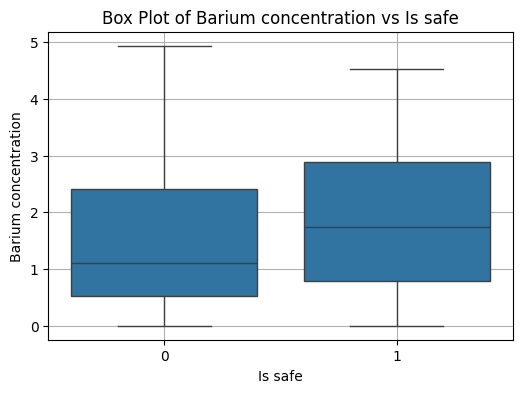

In [45]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="barium", plot_type="boxplot", x_label="Is Safe", y_label="Barium Concentration")

---
<a name = Section2></a>
#### Insights:

- For Is_Safe = 0 (Unsafe Water):
  - 50% of data (IQR) lies within the range of ~0.5 to ~1.5 units per liter
  - The median is approximately 1.0 unit per liter
  - The lower whisker extends to approximately 0.2 units per liter
  - The upper whisker extends to approximately 5.0 units per liter
  - Indicates that unsafe water samples have moderate but concentrated barium levels

- For Is_Safe = 1 (Safe Water):
  - 50% of data (IQR) lies within a wider range of ~0.8 to ~2.8 units per liter (more spread than unsafe water)
  - The median is approximately 1.8 units per liter (higher than unsafe water)
  - The lower whisker extends to approximately 0.3 units per liter
  - The upper whisker extends to approximately 4.5 units per liter
  - Indicates that safe water samples have higher and more variable barium concentrations

- Comparative Analysis:
  - Positive Correlation:
        - Safe water (1) has a **higher median barium concentration** (~1.8) compared to unsafe water (0) (~1.0)

  - Greater Variability: 
        - Safe water shows a larger interquartile range, suggesting more heterogeneity in barium treatment levels

  - Similar Outlier Ranges: 
        - Both groups exhibit similar upper outlier patterns (around 4.5-5.0 units/liter)

  - Interpretation: 
        - Like aluminium, higher barium levels are associated with safe water, suggesting barium may be intentionally added during water treatment/purification processes

  - Feature Importance: 
        - This pattern is particularly meaningful - barium concentration appears to be a better discriminator than arsenic between safe and unsafe water

**Key Takeaway**: Barium shows a contrary relationship to what would be expected from a contaminant perspective - well-treated (safe) water has higher barium levels, indicating this chemical is likely a by-product or intentional component of the water treatment process rather than a harmful contaminant.

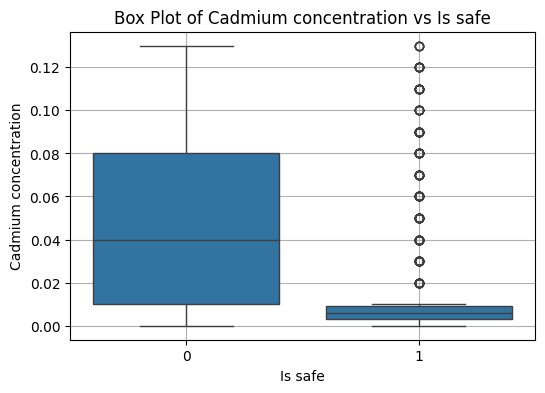

In [46]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="cadmium", plot_type="boxplot", x_label="Is Safe", y_label="Cadmium Concentration")

---
<a name = Section2></a>
#### Insights:

- For Is_Safe = 0 (Unsafe Water):
  - 50% of data (IQR) lies within the range of ~0.01 to ~0.08 units per liter
  - The median is approximately 0.04 units per liter
  - The lower whisker extends to approximately 0.0 units per liter
  - The upper whisker extends to approximately 0.13 units per liter
  - Indicates that unsafe water samples have **notable cadmium contamination**

- For Is_Safe = 1 (Safe Water):
  - 50% of data (IQR) is extremely compressed, concentrated very close to 0
  - The median is essentially 0.0 units per liter (extremely tight concentration)
  - The lower whisker is at 0.0 units per liter
  - The upper whisker extends to only ~0.01 units per liter
  - **Numerous outliers** extending upward from ~0.02 to ~0.13 units per liter
  - Indicates that safe water samples have **minimal central cadmium**, but with anomalous high-contamination samples

- Comparative Analysis:
  - INVERSE & STRONG Correlation: 
    - Safe water (1) has a **significantly lower median cadmium concentration** (~0.0) compared to unsafe water (0) (~0.04)
  - Critical Difference: 
    - This is the **OPPOSITE pattern** from aluminium and barium
  - True Contaminant Signal: 
    - Cadmium shows behavior consistent with a **genuine harmful contaminant** - high in unsafe water, low in safe water
  - Outlier Interpretation: 
    - The numerous outliers in safe water suggest data collection or testing anomalies rather than actual contamination patterns
  - Feature Importance: 
    - Cadmium appears to be an **excellent predictive feature** for water safety classification due to its clear discriminatory power

**Key Takeaway**: Unlike aluminium and barium (which are higher in safe water), **cadmium behaves as expected from a contaminant** - it is present at significantly higher levels in unsafe water and nearly absent in safe water. This makes cadmium a strong and intuitive indicator of water quality problems. The clear separation suggests cadmium could be one of the most important features for the Random Forest model to learn water safety classification.

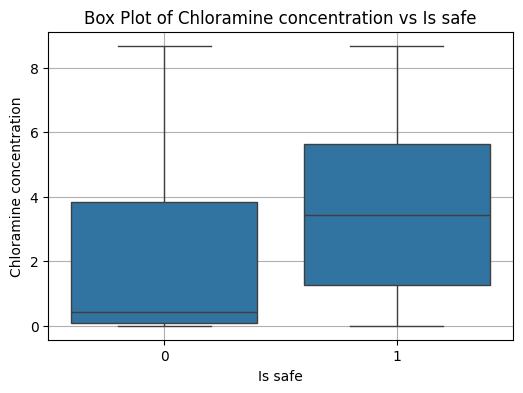

In [47]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="chloramine", plot_type="boxplot", x_label="Is Safe", y_label="Chloramine Concentration")

---
<a name = Section2></a>
#### Insights:

- 

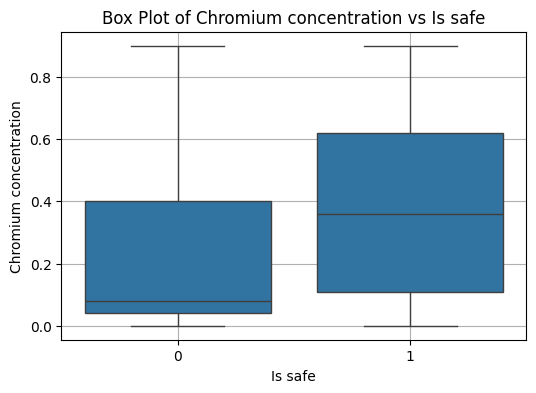

In [48]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="chromium", plot_type="boxplot", x_label="Is Safe", y_label="Chromium Concentration")

---
<a name = Section2></a>
#### Insights:

- 

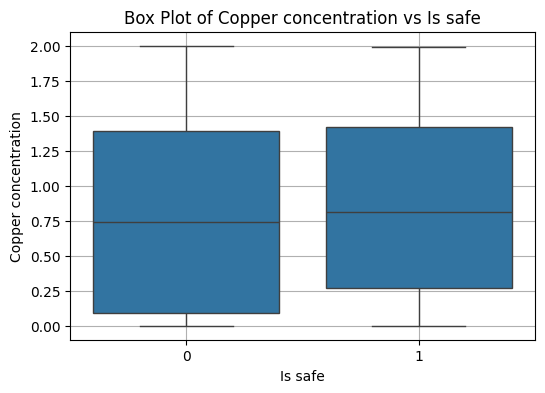

In [49]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="copper", plot_type="boxplot", x_label="Is Safe", y_label="Copper Concentration")

---
<a name = Section2></a>
#### Insights:

- 

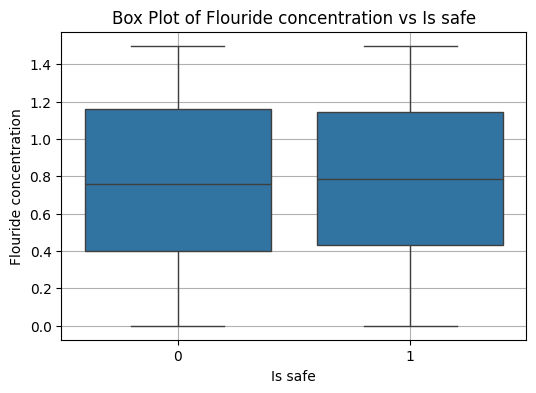

In [50]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="flouride", plot_type="boxplot", x_label="Is Safe", y_label="Flouride Concentration")

---
<a name = Section2></a>
#### Insights:

- 

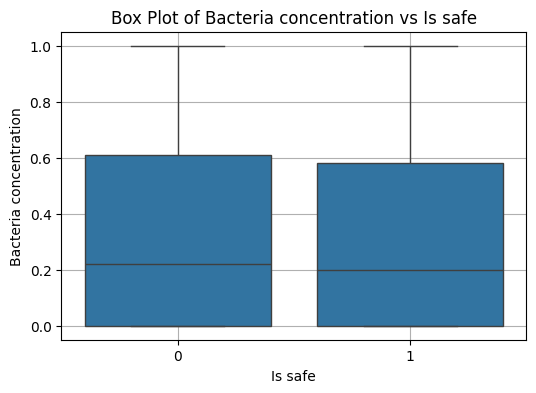

In [51]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="bacteria", plot_type="boxplot", x_label="Is Safe", y_label="Bacteria Concentration")

---
<a name = Section2></a>
#### Insights:

- 

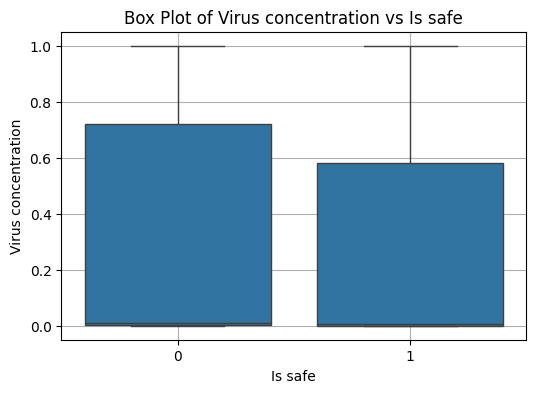

In [52]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="viruses", plot_type="boxplot", x_label="Is Safe", y_label="Virus Concentration")

---
<a name = Section2></a>
#### Insights:

- 

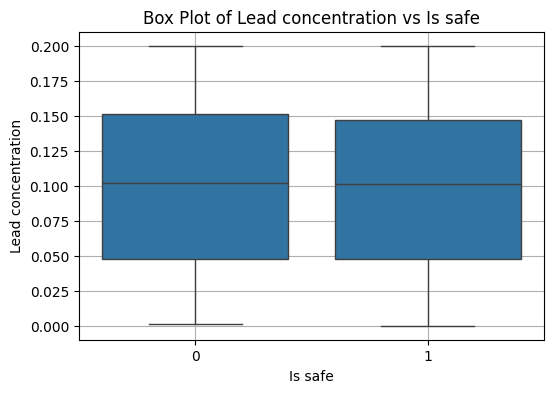

In [53]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="lead", plot_type="boxplot", x_label="Is Safe", y_label="Lead Concentration")

---
<a name = Section2></a>
#### Insights:

- 

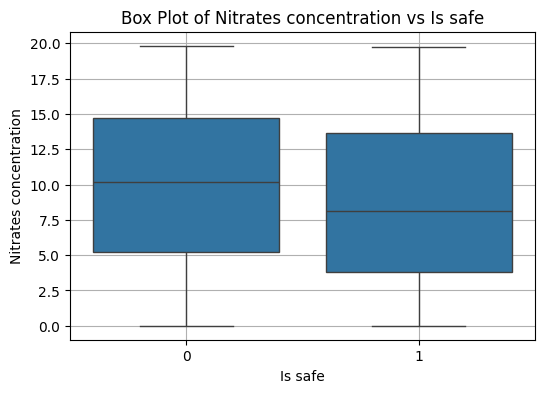

In [54]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="nitrates", plot_type="boxplot", x_label="Is Safe", y_label="Nitrates Concentration")

---
<a name = Section2></a>
#### Insights:

- 

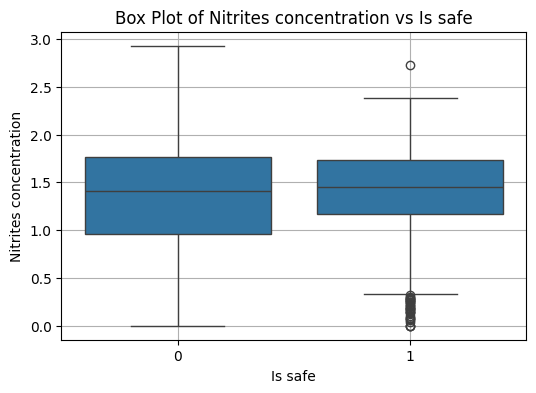

In [55]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="nitrites", plot_type="boxplot", x_label="Is Safe", y_label="Nitrites Concentration")

---
<a name = Section2></a>
#### Insights:

- 

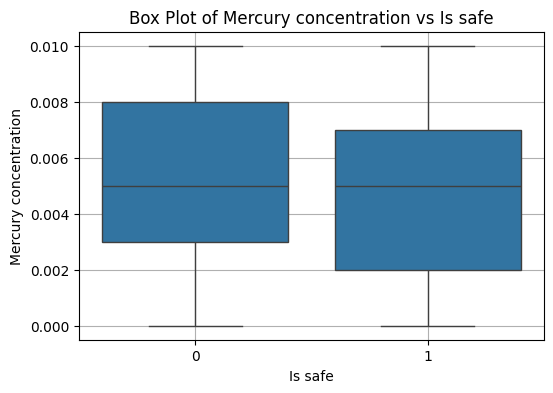

In [56]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="mercury", plot_type="boxplot", x_label="Is Safe", y_label="Mercury Concentration")

---
<a name = Section2></a>
#### Insights:

- 

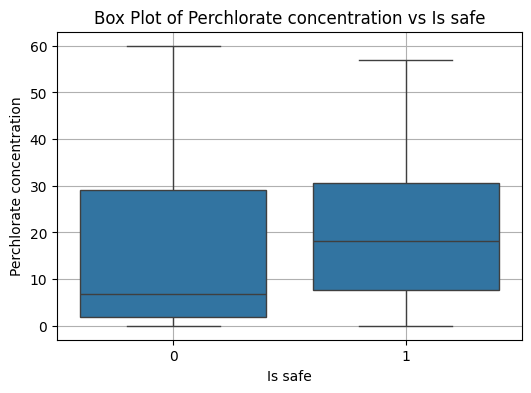

In [57]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="perchlorate", plot_type="boxplot", x_label="Is Safe", y_label="Perchlorate Concentration")

---
<a name = Section2></a>
#### Insights:

- 

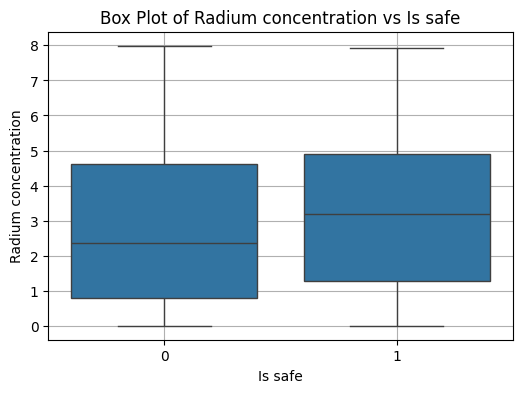

In [58]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="radium", plot_type="boxplot", x_label="Is Safe", y_label="Radium Concentration")

---
<a name = Section2></a>
#### Insights:

- 

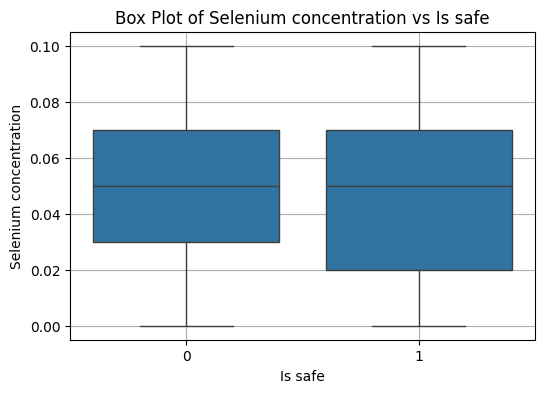

In [59]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="selenium", plot_type="boxplot", x_label="Is Safe", y_label="Selenium Concentration")

---
<a name = Section2></a>
#### Insights:

- 

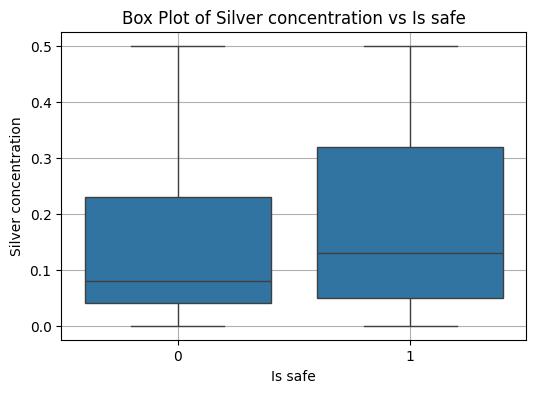

In [60]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="silver", plot_type="boxplot", x_label="Is Safe", y_label="Silver Concentration")

---
<a name = Section2></a>
#### Insights:

- 

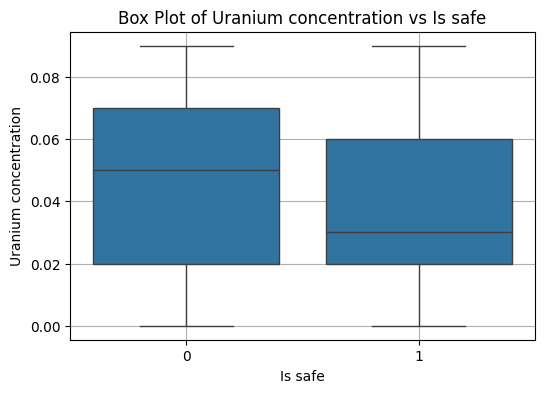

In [61]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="uranium", plot_type="boxplot", x_label="Is Safe", y_label="Uranium Concentration")

---
<a name = Section2></a>
#### Insights:

- 

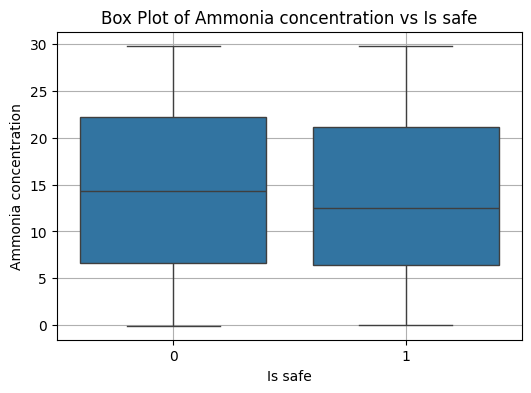

In [62]:
plot_bivariate_relationship(clean_data, x_column="is_safe", y_column="ammonia", plot_type="boxplot", x_label="Is Safe", y_label="Ammonia Concentration")

---
<a name = Section2></a>
#### Insights:

- 


<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Multivariate Analysis</u></li>
</ul>
</p>

---


In [63]:
corr_matrix = clean_data.corr()
corr_matrix

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,viruses,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
aluminium,1.00000,0.06737,0.22573,0.29409,-0.09990,0.36922,0.35313,0.16857,-0.00988,-0.07832,-0.07104,0.02096,-0.00385,0.23744,-0.00313,0.36299,0.24340,-0.00365,0.33492,0.01472,0.33397
ammonia,0.06737,1.00000,0.04678,0.07010,-0.00642,0.10478,0.12478,0.01595,-0.02822,0.06360,0.10586,-0.03706,0.00648,-0.06331,0.02088,0.09093,0.05040,0.02990,0.07555,0.01463,-0.02292
arsenic,0.22573,0.04678,1.00000,0.36292,0.33478,0.35651,0.31242,-0.03649,0.00373,0.03564,0.01160,-0.08767,0.02753,0.30511,-0.01529,0.33223,0.21833,-0.00699,0.30779,0.00147,-0.12336
barium,0.29409,0.07010,0.36292,1.00000,-0.03790,0.44687,0.41594,0.06528,-0.01864,0.10130,-0.00243,-0.04283,-0.01142,0.31278,0.00616,0.46221,0.28689,0.03522,0.43154,-0.00254,0.09086
cadmium,-0.09990,-0.00642,0.33478,-0.03790,1.00000,-0.14437,-0.15772,-0.10925,0.00501,-0.09213,0.02125,-0.03531,0.02023,-0.01583,-0.01617,-0.14927,-0.09894,0.00993,-0.15544,-0.00591,-0.25603
chloramine,0.36922,0.10478,0.35651,0.44687,-0.14437,1.00000,0.55585,0.11897,0.00425,0.15444,0.00343,-0.03024,-0.00162,0.37992,-0.02120,0.58868,0.38912,0.01144,0.52237,-0.00765,0.18670
chromium,0.35313,0.12478,0.31242,0.41594,-0.15772,0.55585,1.00000,0.11300,-0.00242,0.14194,0.00219,-0.05025,-0.01284,0.33594,-0.02254,0.52443,0.31548,0.03060,0.51071,-0.00547,0.18231
copper,0.16857,0.01595,-0.03649,0.06528,-0.10925,0.11897,0.11300,1.00000,0.01165,0.14927,0.00618,0.12176,0.00226,0.16209,0.01778,0.10453,0.02653,-0.00336,0.08924,0.00680,0.02950
flouride,-0.00988,-0.02822,0.00373,-0.01864,0.00501,0.00425,-0.00242,0.01165,1.00000,0.01398,0.01826,0.01215,-0.00824,-0.01659,-0.00426,-0.01635,0.00768,0.02273,0.01445,0.01685,0.00655
bacteria,-0.07832,0.06360,0.03564,0.10130,-0.09213,0.15444,0.14194,0.14927,0.01398,1.00000,0.61853,-0.02718,-0.03399,0.24646,-0.00441,0.14753,0.09908,-0.00678,0.14820,0.04508,-0.02208


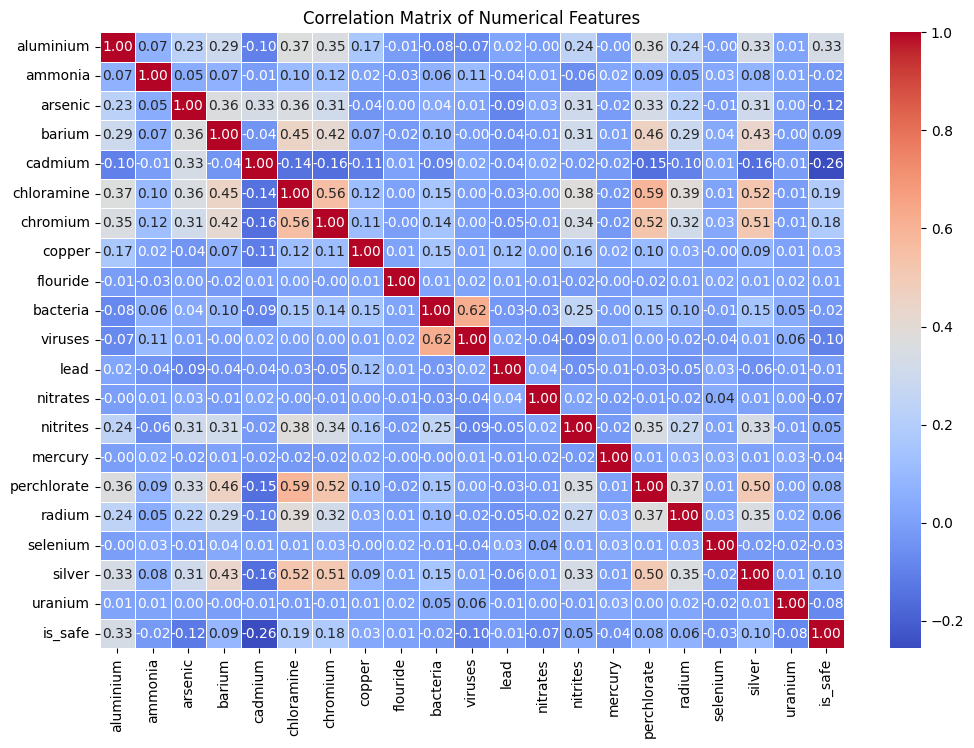

In [64]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [65]:
def winsorize_iqr_by_class(df, group_col='is_safe', cols=None, k=1.5):
    """
    This function performs winsorization on the specified columns of a DataFrame based on the 
    Interquartile Range (IQR) for each class in a specified grouping column.

    Parameters:
    df (pd.DataFrame): The DataFrame to be processed.
    group_col (str): The name of the column to group by (default is 'is_safe').
    cols (list): The list of columns to be winsorized (default is None, which means all columns).
    k (float): The multiplier for the IQR (default is 1.5).

    Returns:
    pd.DataFrame: A DataFrame with the specified columns winsorized based on the IQR for each class.
    """

    if cols is None:
        cols = df.columns.tolist()

    bounds =pd.DataFrame(columns=["Column", "Lower Bound", "Upper Bound"])

    for col in cols:
        # Grouping the DataFrame by the specified grouping column and calculating the IQR for each group
        grouped = df.groupby(group_col)[col]
        Q1 = grouped.transform(lambda x: x.quantile(0.25))
        Q3 = grouped.transform(lambda x: x.quantile(0.75))
        IQR = Q3 - Q1

        # Calculating the lower and upper bounds for winsorization
        lower_bound = Q1 - k * IQR
        upper_bound = Q3 + k * IQR

        sub_bounds = pd.DataFrame({
            'Column': col,
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound
        })
        
        if len(bounds) == 0:
            bounds = sub_bounds
        else:
            if col not in bounds['Column'].values:
                bounds = pd.concat([bounds, sub_bounds], ignore_index=True)

        # Applying winsorization to the specified column based on the calculated bounds
        df[col] = np.where(df[col] < lower_bound, lower_bound, np.where(df[col] > upper_bound, upper_bound, df[col]))

    return df, bounds.drop_duplicates(keep='first')

In [66]:
df_clean = clean_data.copy()
winsorization_columns = ['aluminium', 'arsenic', 'cadmium', 'nitrites']
df_clean, bounds = winsorize_iqr_by_class(df_clean, group_col='is_safe', cols=winsorization_columns, k=1.5)

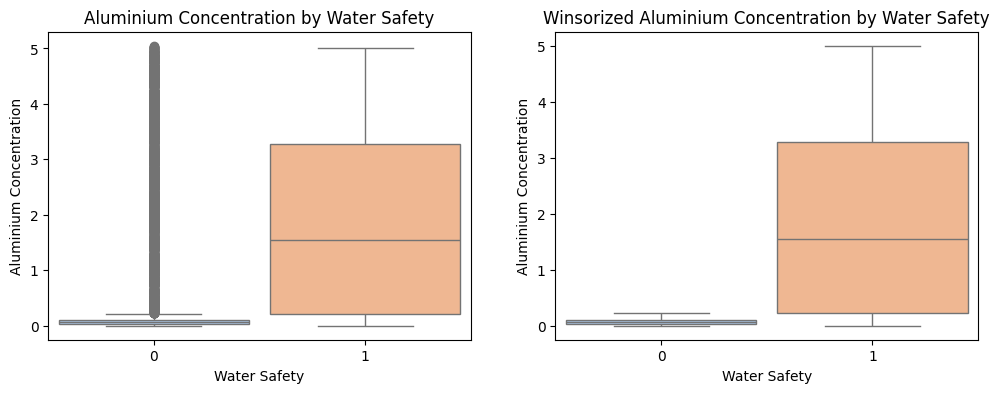

In [67]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['is_safe'], y=clean_data['aluminium'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Aluminium Concentration by Water Safety')
ax1.set_xlabel('Water Safety')
ax1.set_ylabel('Aluminium Concentration')

sns.boxplot(x=df_clean['is_safe'], y=df_clean['aluminium'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Winsorized Aluminium Concentration by Water Safety')
ax2.set_xlabel('Water Safety')
ax2.set_ylabel('Aluminium Concentration')
plt.show()

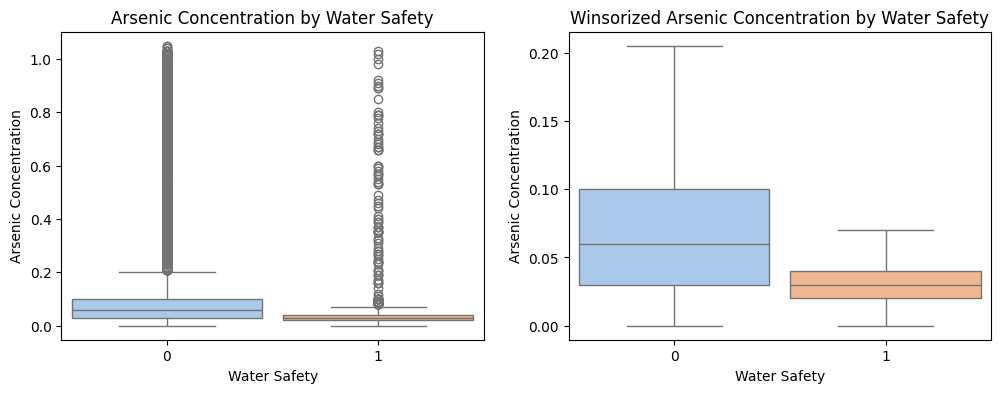

In [68]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['is_safe'], y=clean_data['arsenic'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Arsenic Concentration by Water Safety')
ax1.set_xlabel('Water Safety')
ax1.set_ylabel('Arsenic Concentration')

sns.boxplot(x=df_clean['is_safe'], y=df_clean['arsenic'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Winsorized Arsenic Concentration by Water Safety')
ax2.set_xlabel('Water Safety')
ax2.set_ylabel('Arsenic Concentration')
plt.show()

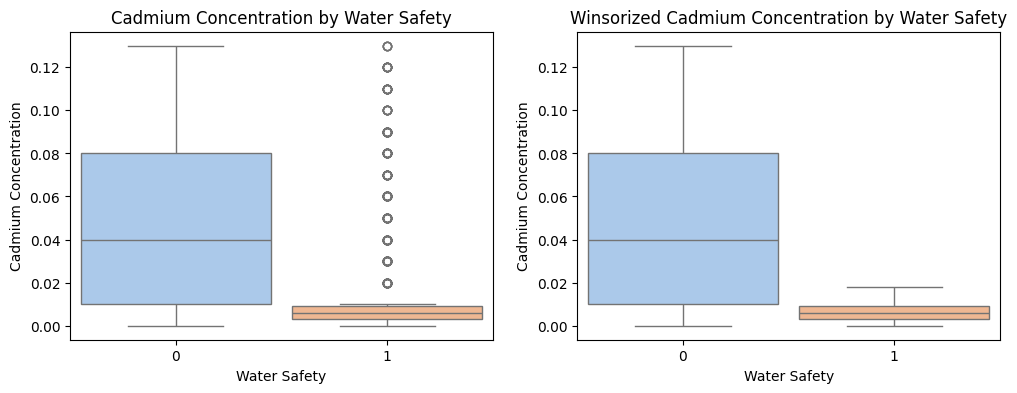

In [69]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['is_safe'], y=clean_data['cadmium'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Cadmium Concentration by Water Safety')
ax1.set_xlabel('Water Safety')
ax1.set_ylabel('Cadmium Concentration')

sns.boxplot(x=df_clean['is_safe'], y=df_clean['cadmium'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Winsorized Cadmium Concentration by Water Safety')
ax2.set_xlabel('Water Safety')
ax2.set_ylabel('Cadmium Concentration')
plt.show()

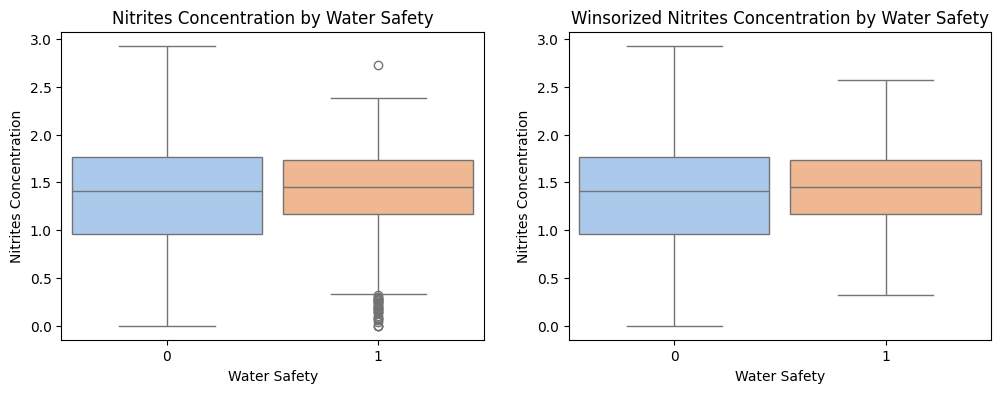

In [70]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.boxplot(x=clean_data['is_safe'], y=clean_data['nitrites'],width=0.9,palette='pastel', ax=ax1)
ax1.set_title('Nitrites Concentration by Water Safety')
ax1.set_xlabel('Water Safety')
ax1.set_ylabel('Nitrites Concentration')

sns.boxplot(x=df_clean['is_safe'], y=df_clean['nitrites'],width=0.9,palette='pastel', ax=ax2)
ax2.set_title('Winsorized Nitrites Concentration by Water Safety')
ax2.set_xlabel('Water Safety')
ax2.set_ylabel('Nitrites Concentration')
plt.show()

<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">2. Random Forest Parameters:</h3>


In [71]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7996 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7996 non-null   float64
 1   ammonia      7996 non-null   float64
 2   arsenic      7996 non-null   float64
 3   barium       7996 non-null   float64
 4   cadmium      7996 non-null   float64
 5   chloramine   7996 non-null   float64
 6   chromium     7996 non-null   float64
 7   copper       7996 non-null   float64
 8   flouride     7996 non-null   float64
 9   bacteria     7996 non-null   float64
 10  viruses      7996 non-null   float64
 11  lead         7996 non-null   float64
 12  nitrates     7996 non-null   float64
 13  nitrites     7996 non-null   float64
 14  mercury      7996 non-null   float64
 15  perchlorate  7996 non-null   float64
 16  radium       7996 non-null   float64
 17  selenium     7996 non-null   float64
 18  silver       7996 non-null   float64
 19  uranium    

In [72]:
X = df_clean.drop(columns=['is_safe'])
y = df_clean['is_safe']

df_clean.shape, X.shape, y.shape

((7996, 21), (7996, 20), (7996,))

In [73]:
X_main, X_test, y_main, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

validation_ratio = 0.15
remaining_ratio = 1.0 - 0.15
adj_validation_size = validation_ratio / remaining_ratio

X_train, X_val, y_train, y_val = train_test_split(X_main, y_main, test_size=adj_validation_size, random_state=42, stratify=y_main)

print(f"Training set size: {len(X_train)} samples")
print(f"Validation set size: {len(X_val)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 5596 samples
Validation set size: 1200 samples
Test set size: 1200 samples


In [74]:
get_proportion_of_categorical_values(df_clean, ["is_safe"])


Proportions for column 'is_safe' in %:
is_safe
0   88.59430
1   11.40570
Name: proportion, dtype: float64
--------------------------------------------------


In [75]:
# Apply SMOTEENN to the training data to address class imbalance by oversampling 
# the minority class and cleaning the data with ENN. This will help improve the 
# performance of our models by providing a more balanced training set and 
# reducing noise from mislabeled or ambiguous samples.
sme = SMOTEENN(random_state=42)

# Fit SMOTEENN on the training data and resample it to create a new training set 
# that is balanced and cleaned. This will generate synthetic samples for the 
# minority class and remove samples that are likely to be noise or misclassified, 
# resulting in a training set that is more suitable for training our machine 
# learning models.
X_train_resampled, y_train_resampled = sme.fit_resample(X_train, y_train)

print(f"Original training set class distribution:\n{y_train.value_counts()}")
print(f"Resampled training set class distribution:\n{pd.Series(y_train_resampled).value_counts()}")


Original training set class distribution:
is_safe
0    4958
1     638
Name: count, dtype: int64
Resampled training set class distribution:
is_safe
1    4656
0    3574
Name: count, dtype: int64


<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">3. Building the Random Forest:</h3>


In [76]:
# Initializing the Random Forest Classifier with specified hyperparameters such as the number of trees 
# (n_estimators), maximum depth of the trees (max_depth), random state for reproducibility, and n_jobs 
# for parallel processing to speed up training.
# n_jobs=-1 tells scikit-learn to use ALL available CPU cores to train the Random Forest model, which 
# can significantly reduce training time, especially for large datasets or when using a large number of 
# trees (n_estimators). By setting n_jobs=-1, the model will utilize all available computational 
# resources, allowing for faster training and improved performance.
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
# Fitting the Random Forest model on the resampled training data
rf_model.fit(X_train_resampled, y_train_resampled)
rf_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">4. Model Evaluation:</h3>


In [77]:
y_train_pred = rf_model.predict(X_train_resampled)
accuracy_train = accuracy_score(y_train_resampled, y_train_pred)
print(f"Training Accuracy: {accuracy_train:.4f}")

Training Accuracy: 0.9998


In [78]:
y_val_pred = rf_model.predict(X_val)
accuracy_val = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {accuracy_val:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

Validation Accuracy: 0.9892

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1063
           1       0.95      0.96      0.95       137

    accuracy                           0.99      1200
   macro avg       0.97      0.97      0.97      1200
weighted avg       0.99      0.99      0.99      1200



---
<a name = Section2></a>
#### Insights:

- **Precision**: Accuracy Protector

    - When our Random Forest predicted whether the source of water is safe or not, how often it is actually right? 
    
        - For predicted  value = 0 : Precision = 0.99, it means 1 out of 100 prediction of value = 0 was a false alarm
        - For predicted  value = 1 : Precision = 0.95, it means 5 out of 100 prediction of value = 1 were false alarm
        
- **Recall**: Prediction Accuracy Finder

    - When our Random Forest predicted whether the source of water is safe or not, how many did our model predicted accurately? 
    
        - For predicted  value = 0 : Recall = 0.99, it means, the model successfully identified 99% of unsafe water and missed 1% of them
        - For predicted  value = 1 : Recall = 0.96, it means, the model successfully identified 96% of safe water and missed 4% of them

In [79]:
y_test_pred = rf_model.predict(X_test)
accuracy_test = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {accuracy_test:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.9867

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1063
           1       0.94      0.95      0.94       137

    accuracy                           0.99      1200
   macro avg       0.96      0.97      0.97      1200
weighted avg       0.99      0.99      0.99      1200



<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">5. Hyperparameter Tuning and Optimization:</h3>


In [80]:
# Define the parameter distribution for Random Search
param_distributions = {
    'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [5, 10, 15, 20, 30, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy']
}

# Initialize RandomSearchCV
# n_iter: number of parameter combinations to sample (e.g., 20 means 20 random combinations)
# cv: cross-validation folds (KFold with 5 splits)
# scoring: metric to optimize ('accuracy', 'f1', 'roc_auc', etc.)
# n_jobs=-1: use all CPU cores
# verbose: print progress (0=silent, 1=progress bar, 2=detailed)
# random_state: for reproducibility
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=20,  # number of random combinations to test
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit the RandomSearchCV on your training data
print("Starting Random Search...")
random_search.fit(X_train_resampled, y_train_resampled)

print(f"\nBest Parameters: {random_search.best_params_}")
print(f"Best Cross-Validation Score: {random_search.best_score_:.4f}")

Starting Random Search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15, 'criterion': 'gini', 'bootstrap': False}
Best Cross-Validation Score: 0.9979


In [81]:
print(f"Scorer Used: {random_search.scorer_}")
best_model = random_search.best_estimator_

Scorer Used: make_scorer(f1_score, response_method='predict', average=binary)


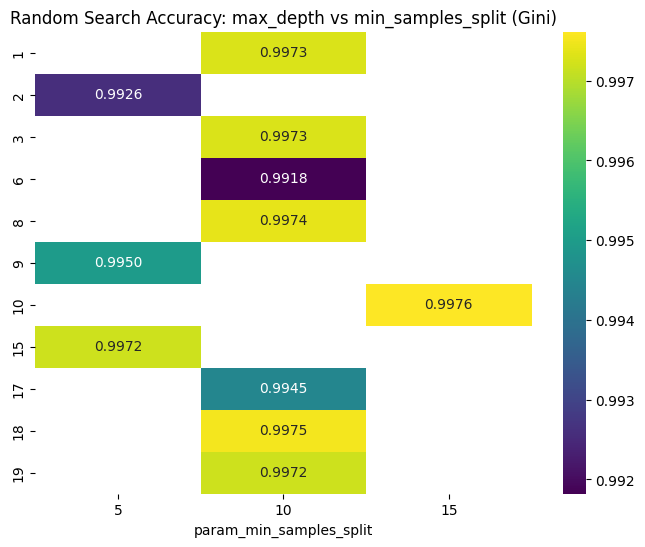

In [82]:
# 1. Convert random search results to a DataFrame
results_df = pd.DataFrame(random_search.cv_results_)

# 2. Filter for one criterion (e.g., 'entropy') to visualize the effect of max_depth and min_samples_split
viz_data = results_df[results_df['param_criterion'] == 'entropy']

# 3. Pivot the data: Rows = max_depth, Columns = min_samples_split 
pivot_table = viz_data.pivot(
                             columns='param_min_samples_split', 
                             values='mean_test_score')

# 4. Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt='.4f')
plt.title('Random Search Accuracy: max_depth vs min_samples_split (Gini)')
plt.show()

In [83]:
# Training accuracy
y_train_pred_rs = best_model.predict(X_train_resampled)
accuracy_train_rs = accuracy_score(y_train_resampled, y_train_pred_rs)

# Validation accuracy
y_val_pred_rs = best_model.predict(X_val)
accuracy_val_rs = accuracy_score(y_val, y_val_pred_rs)

# Test accuracy
y_test_pred_rs = best_model.predict(X_test)
accuracy_test_rs = accuracy_score(y_test, y_test_pred_rs)

print(f"Train Accuracy: {accuracy_train_rs:.4f}")
print(f"Validation Accuracy: {accuracy_val_rs:.4f}")
print(f"Test Accuracy: {accuracy_test_rs:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_rs))

Train Accuracy: 1.0000
Validation Accuracy: 0.9900
Test Accuracy: 0.9892

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1063
           1       0.96      0.94      0.95       137

    accuracy                           0.99      1200
   macro avg       0.98      0.97      0.97      1200
weighted avg       0.99      0.99      0.99      1200



In [84]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Initial RF', 'RandomSearchCV'],
    'Train Accuracy': [accuracy_train, accuracy_train_rs],
    'Validation Accuracy': [accuracy_val, accuracy_val_rs],
    'Test Accuracy': [accuracy_test, accuracy_test_rs]
})

print(comparison_df)

            Model  Train Accuracy  Validation Accuracy  Test Accuracy
0      Initial RF         0.99976              0.98917        0.98667
1  RandomSearchCV         1.00000              0.99000        0.98917


Model AUC Grade: 0.9929
Mathematical Optimal Threshold: 0.4753 (or 47.53%)


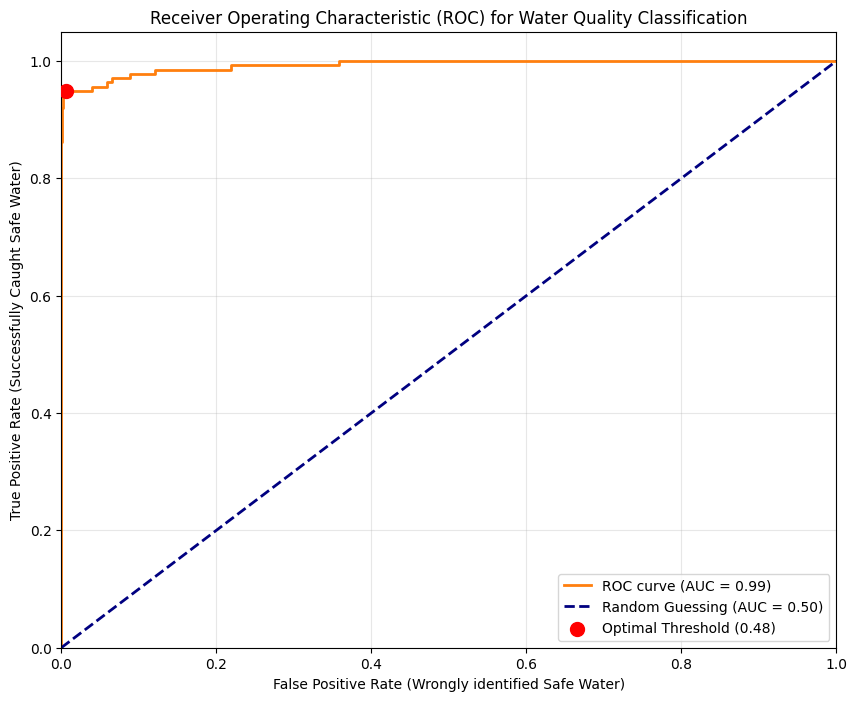

In [85]:
# 1. Get the raw probabilities from the scikit-learn model
# .predict_proba() returns two columns: [Probability of 0, Probability of 1]
# We only want the probabilities of is_safe 1 (Water is Safe), which is the second column (index 1)
y_probs = best_model.predict_proba(X_test)[:, 1]

# 2. Calculate the ROC curve points
# fpr = False Positive Rate, tpr = True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# 3. Calculate the AUC (Area Under the Curve)
auc_score = roc_auc_score(y_test, y_probs)

# 4. Calculate the Optimal Threshold using Youden's J Statistic
# We want the threshold where (TPR - FPR) is at its absolute maximum
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Model AUC Grade: {auc_score:.4f}")
print(f"Mathematical Optimal Threshold: {optimal_threshold:.4f} (or {optimal_threshold*100:.2f}%)")

# 5. Visualize the ROC Curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='#ff7f0e', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.50)')

# Highlight the optimal threshold point on the curve
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', s=100,
            label=f'Optimal Threshold ({optimal_threshold:.2f})', zorder=5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Wrongly identified Safe Water)')
plt.ylabel('True Positive Rate (Successfully Caught Safe Water)')
plt.title('Receiver Operating Characteristic (ROC) for Water Quality Classification')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

---
<a name = Section2></a>
#### Insights:

- By default, machine learning algorithms use a 50% Threshold. If the model thinks there is a 51% chance that the water is safe, it predicts 1. If it's 49%, it predicts 0.
- In the business world, a strict 50% cutoff is almost always a terrible idea, especially for imbalanced data.
- The ROC Curve (Receiver Operating Characteristic) is simply a chart that shows you how your model performs at every single possible threshold from 0% to 100%.

What we want to achieve:-
- True Positive Rate (Recall): How many safe water source we can successfully identify? (We want this to go UP).
- False Positive Rate: How many we wrongly identified as safe water source? (We want this to stay DOWN).

AUC (Area Under the Curve) is the model's final "Letter Grade".
- An AUC of 0.50 means our model is guessing randomly (a useless diagonal line).
- An AUC of 1.00 means our model perfectly separates safe from non-safe.

Finding the "Optimal" Threshold (Youden's J Statistic):
- If we don't want to use 50%, what should we use? Mathematically, the perfect threshold is the point on the ROC curve that is furthest away from the random-guessing diagonal line.
- We find this using Youden's J Statistic, which maximizes the difference between our True Positives and False Positives:

    $J = True Positive Rate - False Positive Rate$

The threshold that gives us the highest $J$ score is the mathematical "sweet spot" of our model.


In [86]:
# 1. Grabing the raw probabilities for the positive class (Is Safe = 1)
y_probs = best_model.predict_proba(X_test)[:, 1]

# 2. Re-create the default 50% predictions for a baseline comparison
y_pred_default = (y_probs >= 0.50).astype(int)

# 3. Apply our newly calculated optimal threshold
# (assuming 'optimal_threshold' variable exists from the previous ROC code block)
y_pred_optimal = (y_probs >= optimal_threshold).astype(int)

# 4. Print the comparison
print("======================================================")
print(" SCENARIO 1: The Default Threshold (50%)")
print("======================================================")
print(classification_report(y_test, y_pred_default))

print("\n======================================================")
print(f" SCENARIO 2: The Optimal Threshold ({optimal_threshold:.2f})")
print("======================================================")
print(classification_report(y_test, y_pred_optimal))

 SCENARIO 1: The Default Threshold (50%)
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1063
           1       0.96      0.94      0.95       137

    accuracy                           0.99      1200
   macro avg       0.98      0.97      0.97      1200
weighted avg       0.99      0.99      0.99      1200


 SCENARIO 2: The Optimal Threshold (0.48)
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1063
           1       0.96      0.95      0.95       137

    accuracy                           0.99      1200
   macro avg       0.97      0.97      0.97      1200
weighted avg       0.99      0.99      0.99      1200



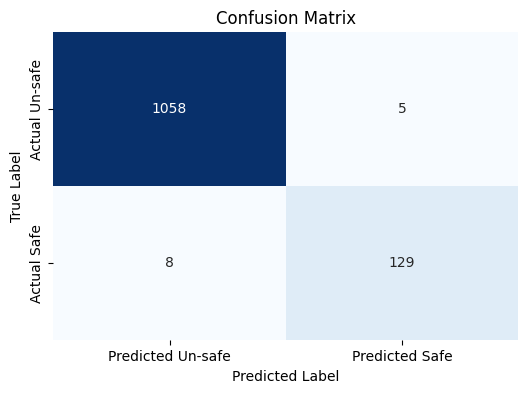

In [92]:
cm = confusion_matrix(y_test, y_test_pred_rs)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Predicted Un-safe', 'Predicted Safe'], 
            yticklabels=['Actual Un-safe', 'Actual Safe'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

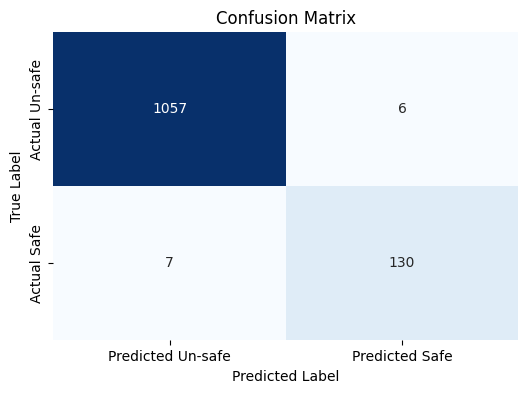

In [93]:
cm = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Predicted Un-safe', 'Predicted Safe'], 
            yticklabels=['Actual Un-safe', 'Actual Safe'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

---
<a name = Section2></a>
#### Insights:

- From the above 2 confusion matrix as well as classification report we can conclude that for this particular scenario we are getting the best predictions with the threshold value >= 0.50

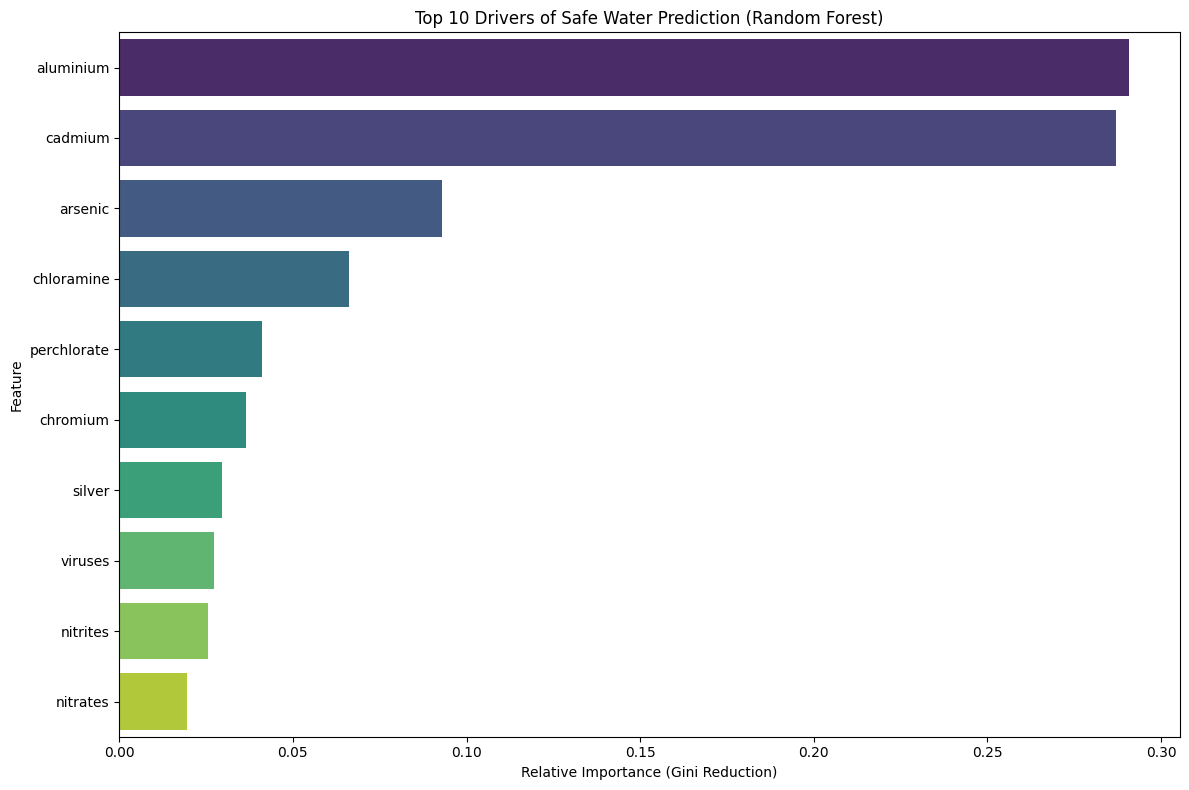

In [87]:
# 1. Extract feature importances from the trained scikit-learn model
importances = best_model.feature_importances_

# 2. Get the feature names from your training dataset
# (Assuming X_train is a pandas DataFrame)
feature_names = X_train.columns

# 3. Create a DataFrame to hold the feature names and their importance scores
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 4. Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 5. Plot the Top 10 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Drivers of Safe Water Prediction (Random Forest)')
plt.xlabel('Relative Importance (Gini Reduction)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [94]:
with open('data\\output\\random_forest_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)